Author: Tuwe Löfström (tuwe.lofstrom@ju.se)  
Copyright 2023 Tuwe Löfström  
License: BSD 3 clause

In [14]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

from calibrated_explanations import WrapCalibratedExplainer, __version__
from calibrated_explanations.calibration import VennAbers

print(f"calibrated_explanations {__version__}")

calibrated_explanations v0.11.1


In [16]:
dataset = "glass"
delimiter = ","
num_to_test = 24
print(dataset)

filename = "../../data/Multiclass/" + dataset + ".csv"
df = pd.read_csv(filename, delimiter=delimiter)
target = "Type"

df = df.dropna()
categorical_features = []
categorical_labels = {}
for c, col in enumerate(df.columns):
    if df[col].dtype == 'object' or df[col].dtype == 'str':
        df[col] = df[col].str.replace("'", "")
        df[col] = df[col].str.replace('"', "")
        if col != target:
            categorical_features.append(c)
            categorical_labels[c] = dict(zip(range(len(np.unique(df[col]))), np.unique(df[col]), strict=False))
        else:
            target_labels = dict(zip(range(len(np.unique(df[col]))), np.unique(df[col]), strict=False))
        mapping = dict(zip(np.unique(df[col]), range(len(np.unique(df[col]))), strict=False))
        if len(mapping) > 5:
            counts = df[col].value_counts().sort_values(ascending=False)
            id = 0
            for key, count in counts.items():
                if count > 5:
                    id += 1
                    continue
                mapping[key] = id
        df[col] = df[col].map(mapping)
print(target_labels)

glass
{0: 'build wind float', 1: 'build wind non-float', 2: 'containers', 3: 'headlamps', 4: 'tableware', 5: 'vehic wind float'}


In [17]:
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.51793,12.79,3.50,1.12,73.03,0.64,8.77,0.0,0.00,0
1,1.51643,12.16,3.52,1.35,72.89,0.57,8.53,0.0,0.00,5
2,1.51793,13.21,3.48,1.41,72.64,0.59,8.43,0.0,0.00,0
3,1.51299,14.40,1.74,1.54,74.55,0.00,7.59,0.0,0.00,4
4,1.53393,12.30,0.00,1.00,70.16,0.12,16.19,0.0,0.24,1


In [18]:
X, y = df.drop(target, axis=1), df[target]
no_of_classes = len(np.unique(y))
no_of_features = X.shape[1]
no_of_instances = X.shape[0]
# sort targets to make sure equal presence of both classes in test set (see definition of test_index after outer loop below)
idx = np.argsort(y.values).astype(int)
X, y = X.values[idx, :], y.values[idx]
test_idx = []
idx = list(range(no_of_instances))
for i in range(no_of_classes):
    test_idx.append(np.where(y == i)[0][0 : int(num_to_test / no_of_classes)])
test_index = np.array(test_idx).flatten()
# Select num_to_test/2 from top and num_to_test/2 from bottom of list of instances
train_index = np.setdiff1d(np.array(range(no_of_instances)), test_index)
x_train, x_test = X[train_index, :], X[test_index, :]
y_train, y_test = y[train_index], y[test_index]
X_prop_train, x_cal, y_prop_train, y_cal = train_test_split(
    x_train, y_train, test_size=0.33, random_state=42, stratify=y_train
)
print(y_test)
print(categorical_features)

[0 0 0 0 1 1 1 1 2 2 2 2 3 3 3 3 4 4 4 4 5 5 5 5]
[]


In [19]:
model = RandomForestClassifier(n_estimators=100)
model_name = "RF"
model.fit(X_prop_train, y_prop_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [20]:
va = VennAbers(x_cal, y_cal, model)
va_proba, low, high, predicted_classes = va.predict_proba(x_test, output_interval=True)
print(
    *zip(
        [low[i, c] for i, c in enumerate(predicted_classes)],
        [va_proba[i, c] for i, c in enumerate(predicted_classes)],
        [high[i, c] for i, c in enumerate(predicted_classes)],
        y_test,
        predicted_classes, strict=False,
    ),
    sep="\n",
)

(np.float64(0.9), np.float64(0.8461538461538461), np.float64(0.9166666666666666), np.int64(0), np.int64(0))
(np.float64(0.5833333333333334), np.float64(0.3516483516483516), np.float64(0.888888888888889), np.int64(0), np.int64(0))
(np.float64(0.5), np.float64(0.3170731707317073), np.float64(0.8125), np.int64(0), np.int64(0))
(np.float64(0.6666666666666666), np.float64(0.40740740740740744), np.float64(0.9166666666666666), np.int64(0), np.int64(0))
(np.float64(0.2), np.float64(0.2), np.float64(0.8125), np.int64(1), np.int64(0))
(np.float64(0.5), np.float64(0.3170731707317073), np.float64(0.8125), np.int64(1), np.int64(0))
(np.float64(0.2), np.float64(0.2), np.float64(0.8125), np.int64(1), np.int64(0))
(np.float64(0.9166666666666666), np.float64(0.7058823529411764), np.float64(1.0), np.int64(1), np.int64(1))
(np.float64(0.5), np.float64(0.29729729729729726), np.float64(0.9166666666666666), np.int64(2), np.int64(2))
(np.float64(0.5), np.float64(0.30188679245283023), np.float64(0.88888888888

In [21]:
print(target_labels, end="\n\nConfusions matrix on test set:\n")

cm = confusion_matrix(y_test, predicted_classes)
print(cm, end="\n\nConfusions matrix on calibration set:\n")

cal_predicted_classes = np.zeros(len(y_cal))
for i in range(len(y_cal)):
    va = VennAbers(
        np.concatenate((x_cal[:i], x_cal[i + 1 :]), axis=0),
        np.concatenate((y_cal[:i], y_cal[i + 1 :])),
        model,
    )
    _, _, _, predict = va.predict_proba([x_cal[i]], output_interval=True)
    cal_predicted_classes[i] = predict[0]
cm = confusion_matrix(y_cal, cal_predicted_classes)

print(cm)

for i in range(no_of_classes):
    print()
    print(f"Class {i} {target_labels[i]}")
    print(f"Precision: {cm[i,i]/np.sum(cm[:,i])}")
    print(f"Recall: {cm[i,i]/np.sum(cm[i,:])}")
    print(f"F1: {2*cm[i,i]/(np.sum(cm[:,i]) + np.sum(cm[i,:]))}")

{0: 'build wind float', 1: 'build wind non-float', 2: 'containers', 3: 'headlamps', 4: 'tableware', 5: 'vehic wind float'}

Confusions matrix on test set:
[[4 0 0 0 0 0]
 [3 1 0 0 0 0]
 [0 1 3 0 0 0]
 [0 0 0 3 1 0]
 [0 2 0 0 2 0]
 [2 2 0 0 0 0]]

Confusions matrix on calibration set:
[[20  1  0  0  0  1]
 [ 4 17  2  0  1  0]
 [ 0  1  1  1  0  0]
 [ 0  1  0  7  0  0]
 [ 0  1  0  0  1  0]
 [ 2  0  0  0  0  2]]

Class 0 build wind float
Precision: 0.7692307692307693
Recall: 0.9090909090909091
F1: 0.8333333333333334

Class 1 build wind non-float
Precision: 0.8095238095238095
Recall: 0.7083333333333334
F1: 0.7555555555555555

Class 2 containers
Precision: 0.3333333333333333
Recall: 0.3333333333333333
F1: 0.3333333333333333

Class 3 headlamps
Precision: 0.875
Recall: 0.875
F1: 0.875

Class 4 tableware
Precision: 0.5
Recall: 0.5
F1: 0.5

Class 5 vehic wind float
Precision: 0.6666666666666666
Recall: 0.5
F1: 0.5714285714285714


In [22]:
ce = WrapCalibratedExplainer(model)
ce.calibrate(x_cal, y_cal, feature_names=df.columns, categorical_features=categorical_features, class_labels=target_labels)
display(ce)

WrapCalibratedExplainer(learner=RandomForestClassifier(), fitted=True, calibrated=True, 
		explainer=CalibratedExplainer(mode=classification, learner=RandomForestClassifier()))

In [23]:
factual_explanations = ce.explain_factual(x_test)

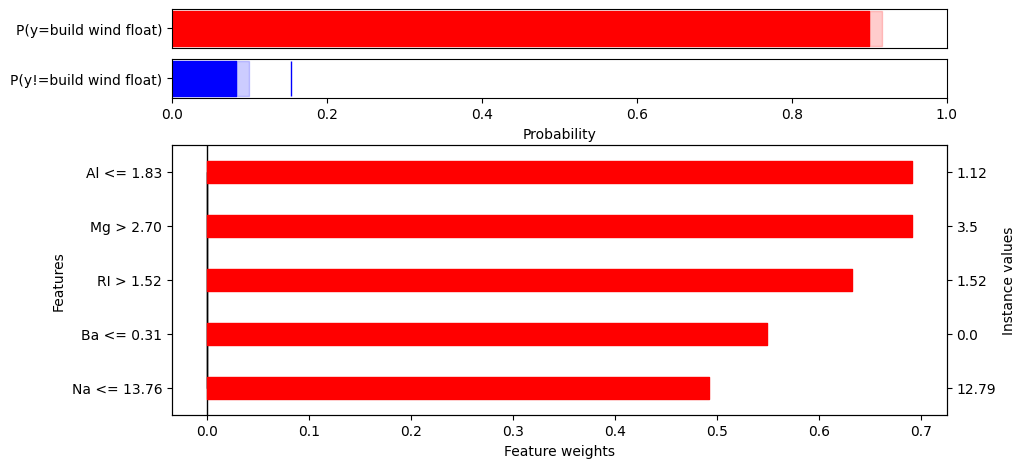

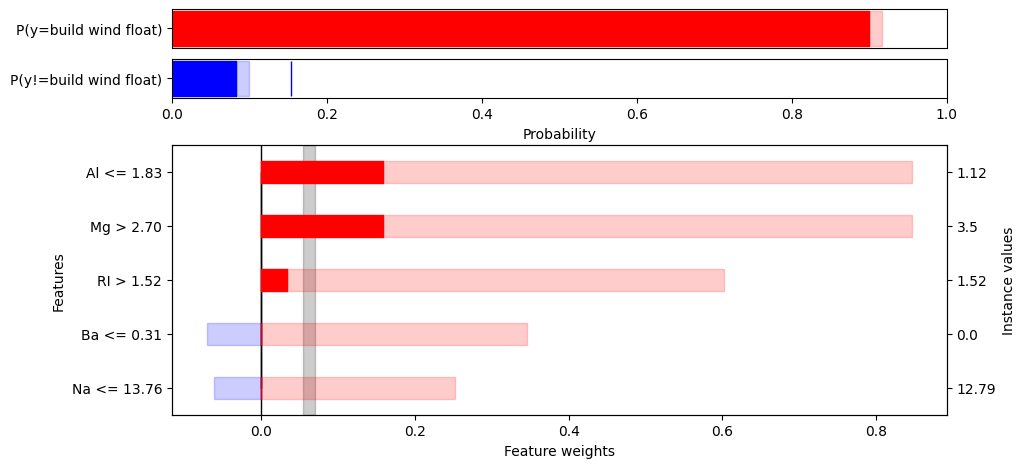

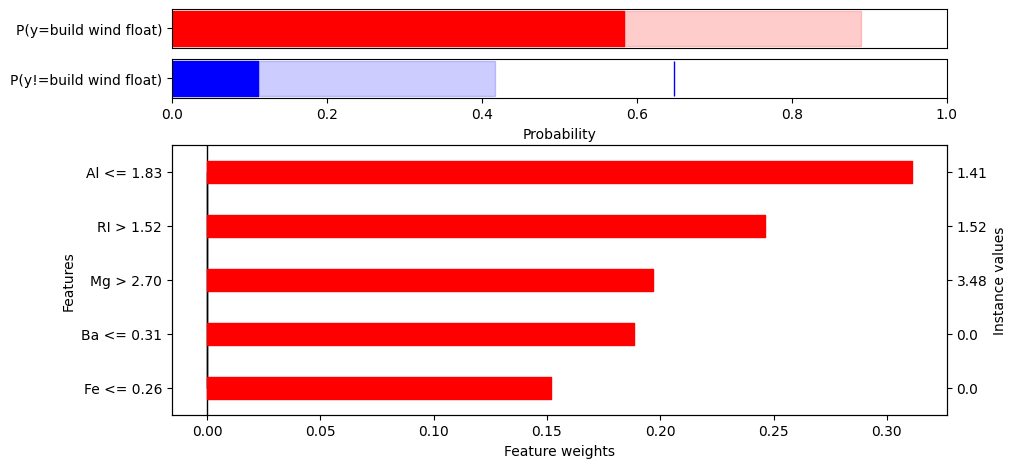

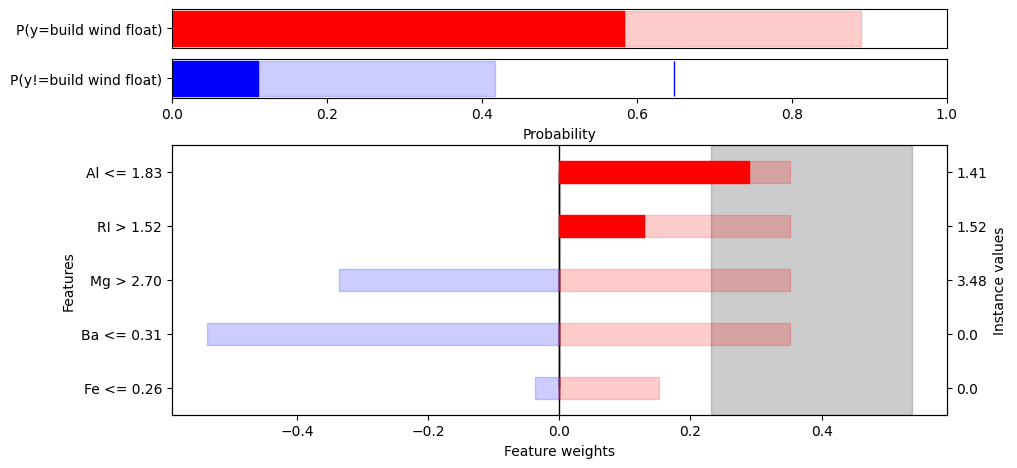

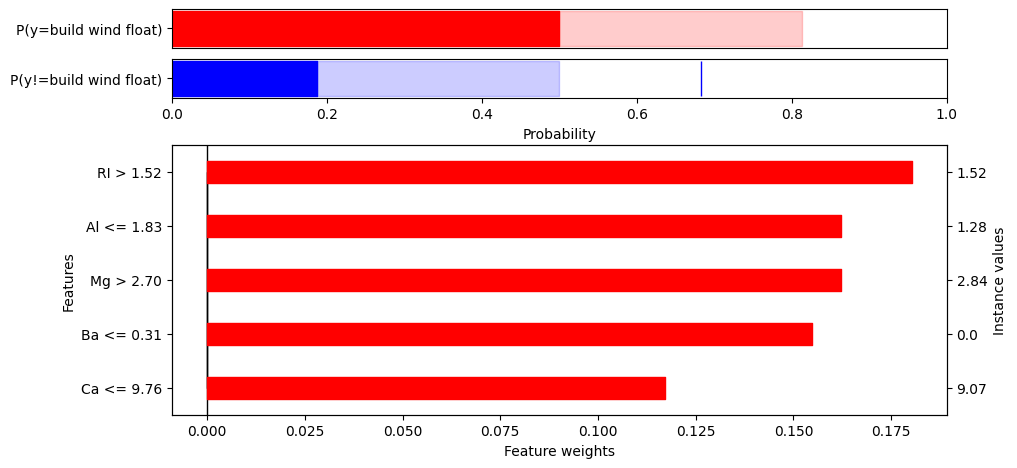

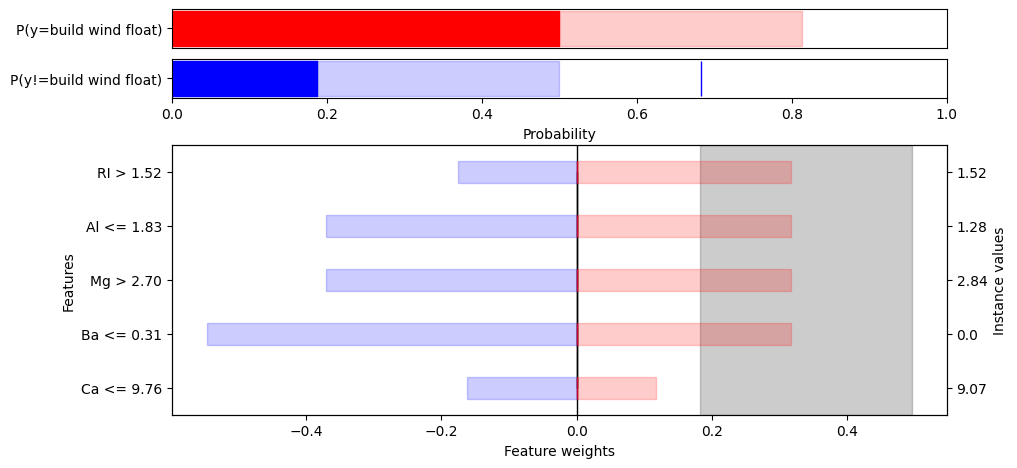

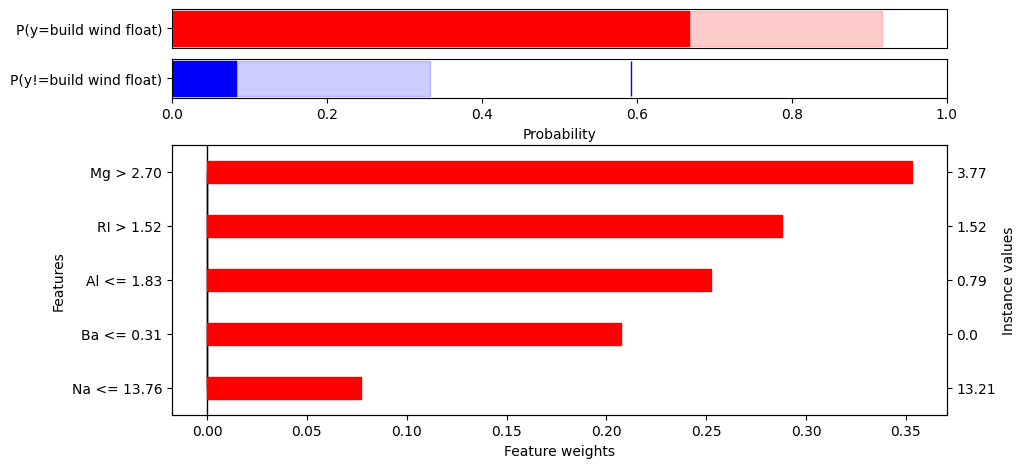

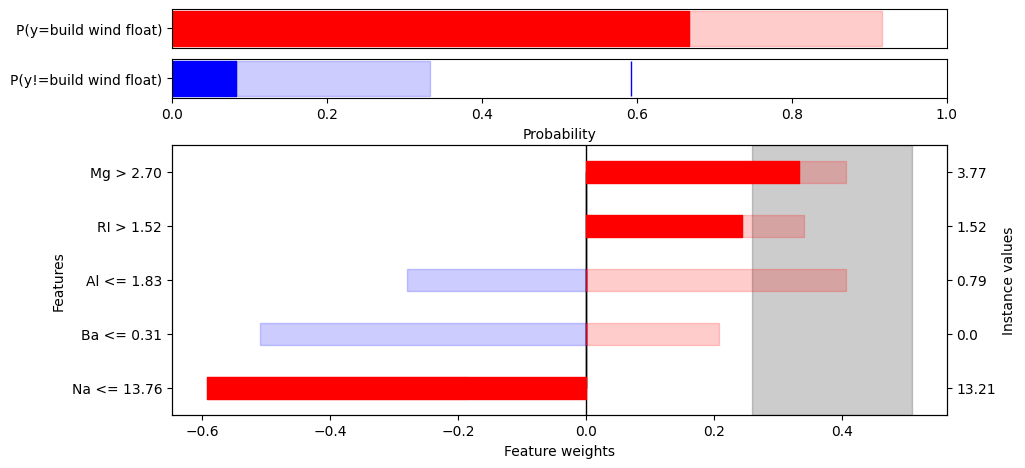

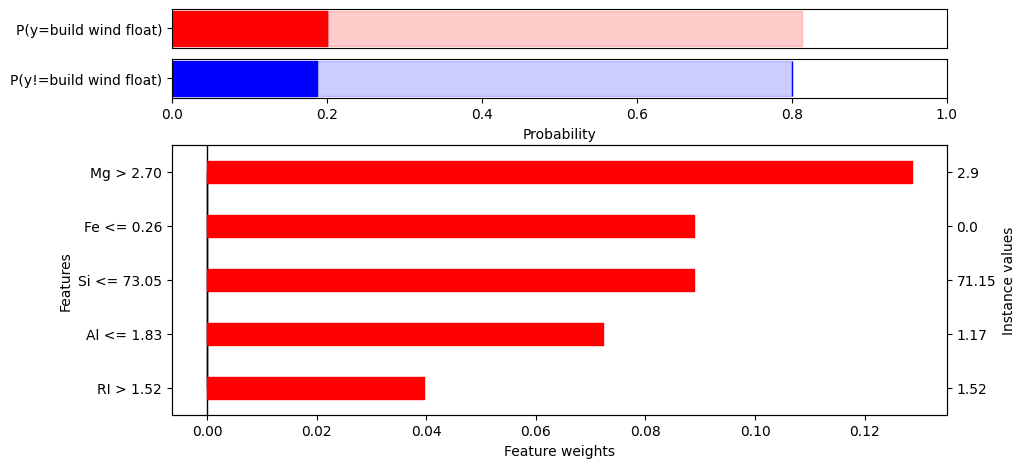

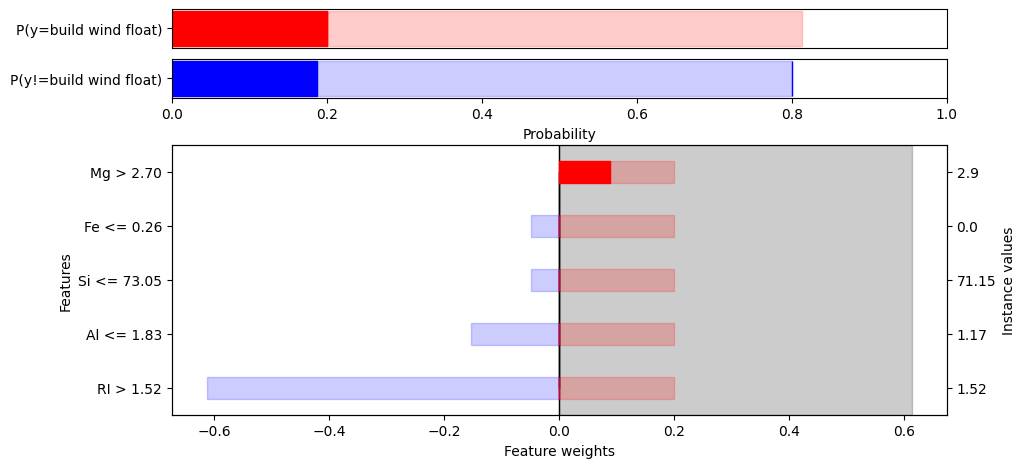

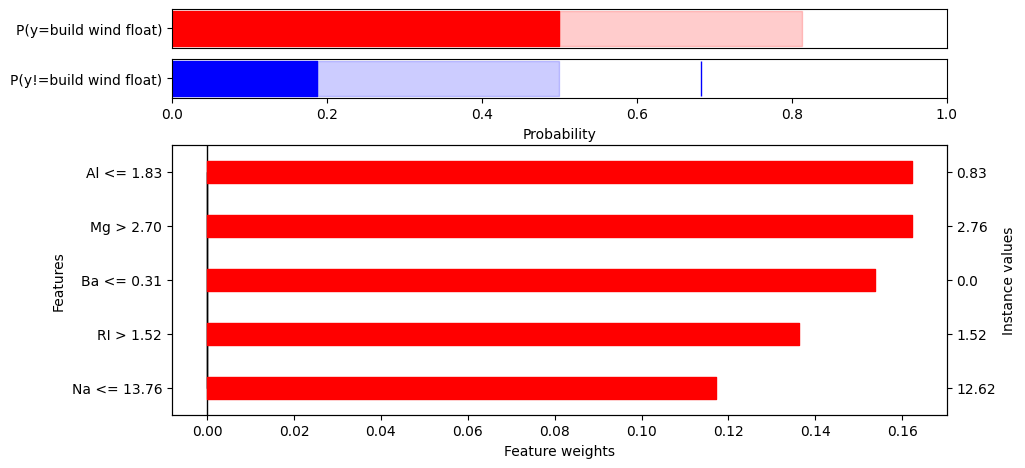

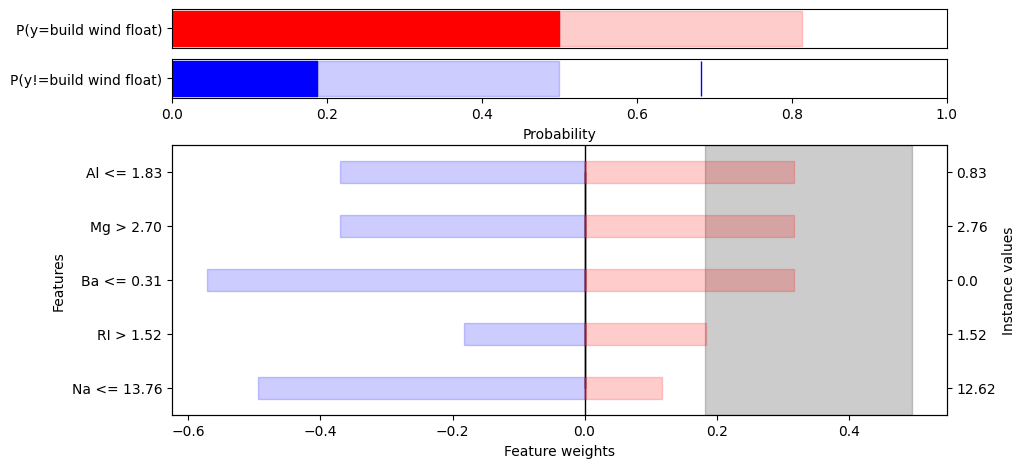

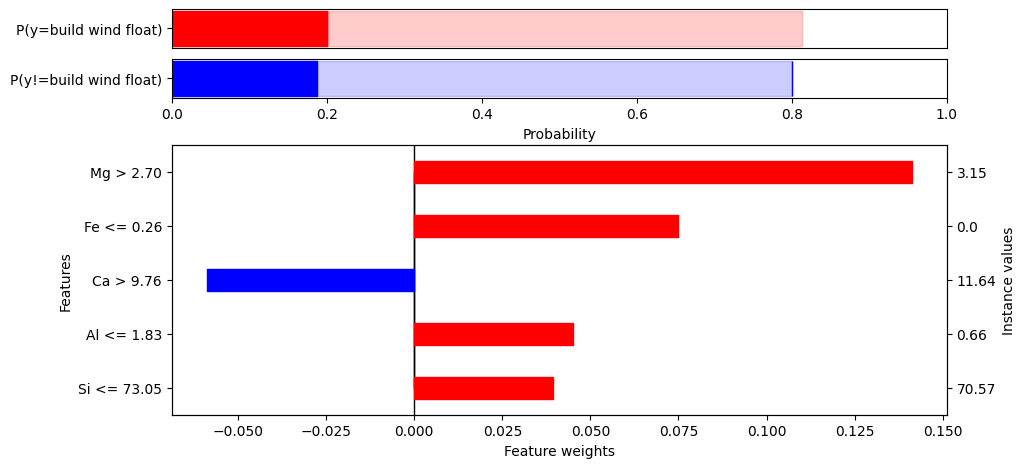

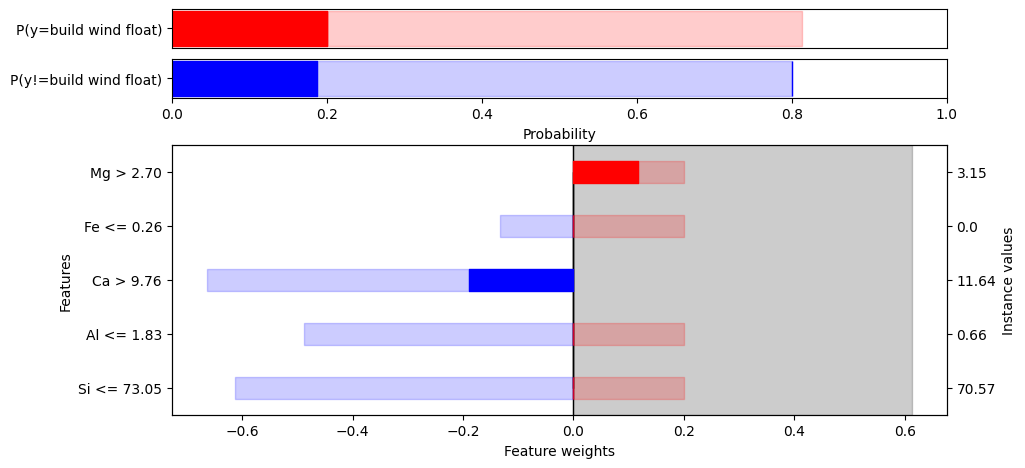

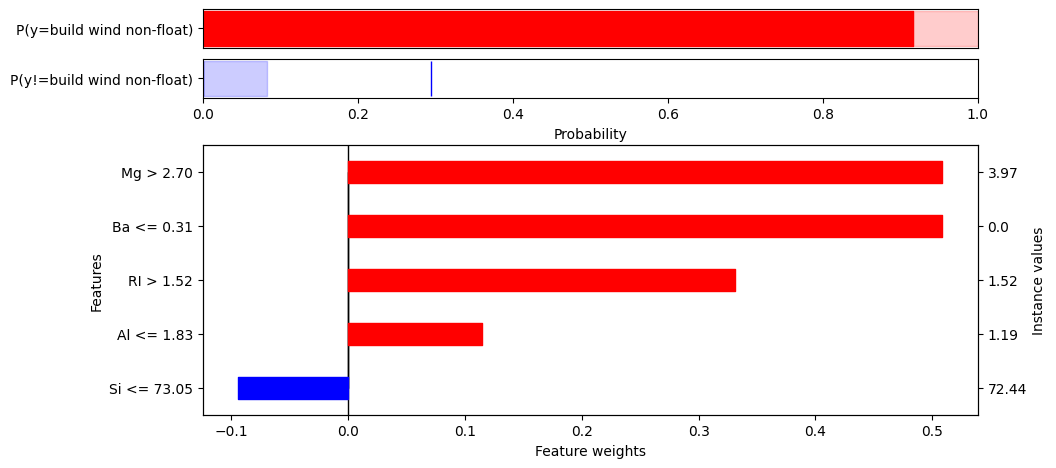

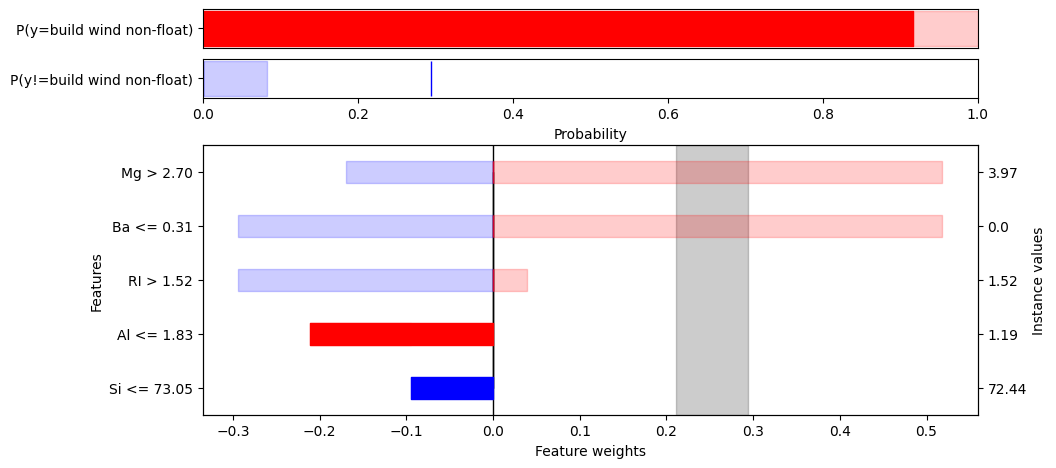

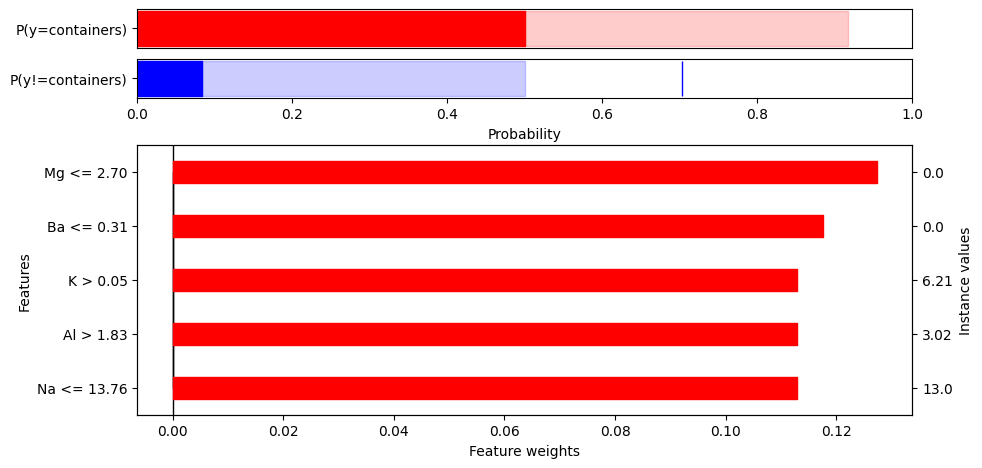

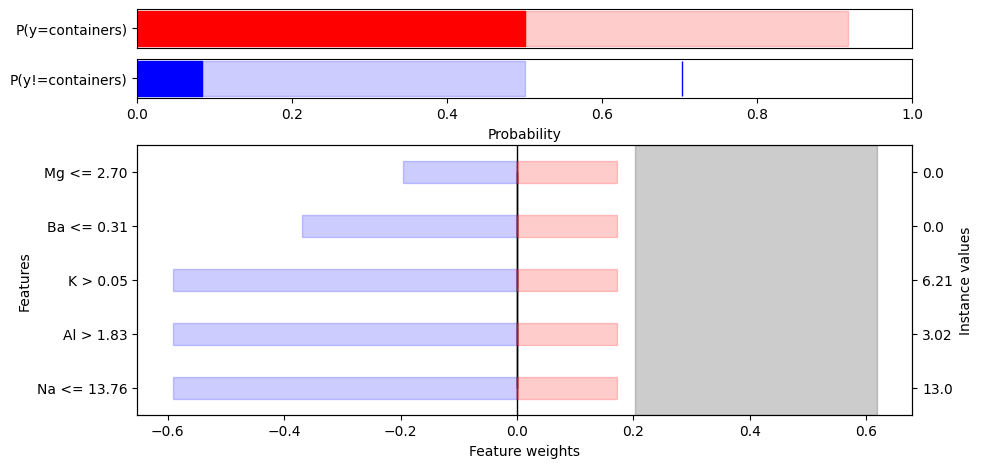

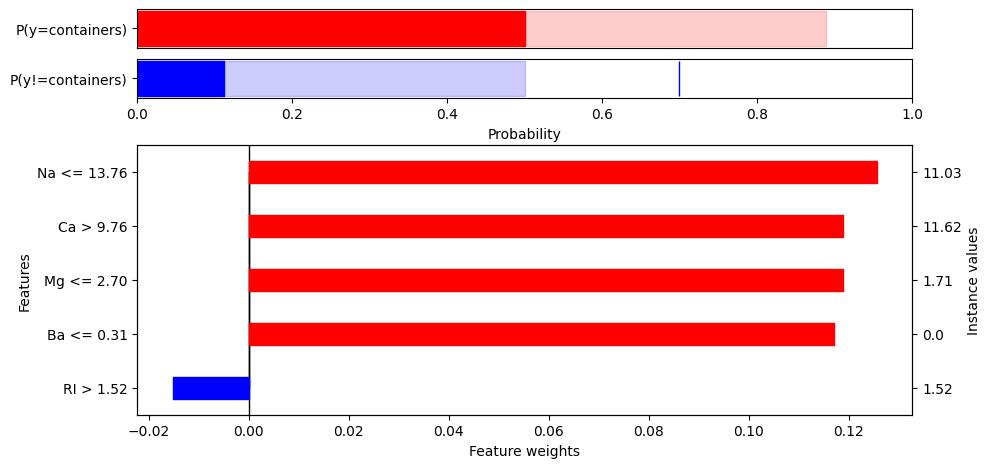

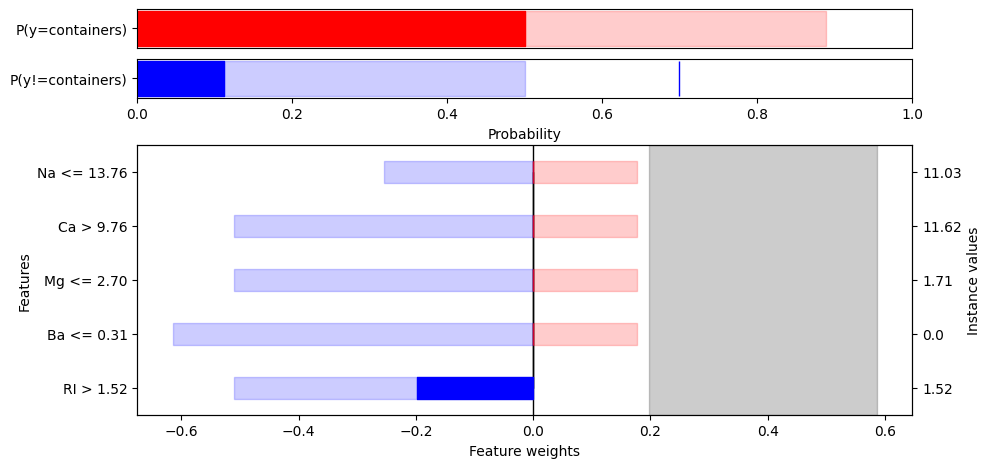

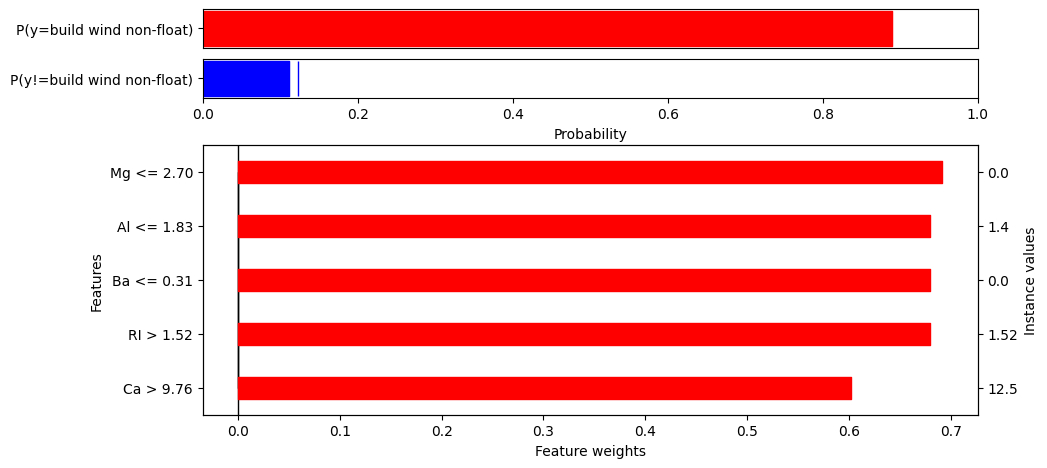

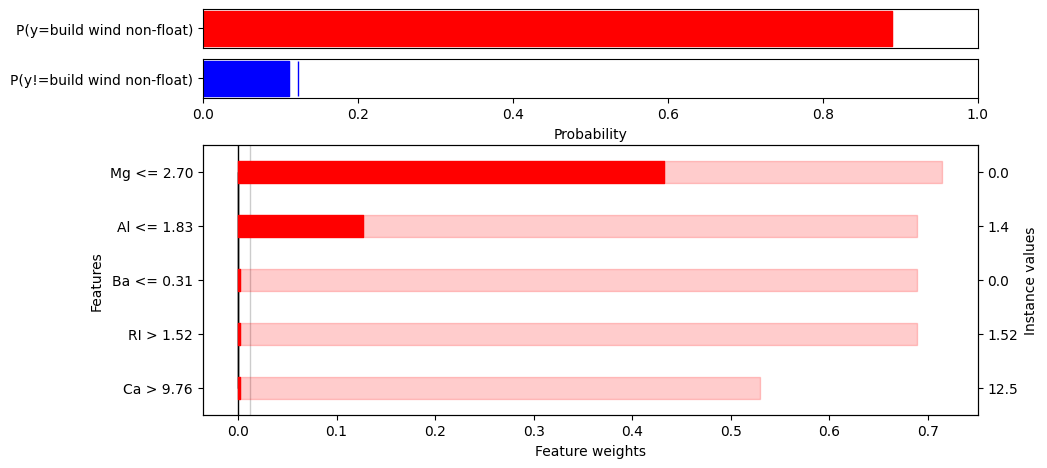

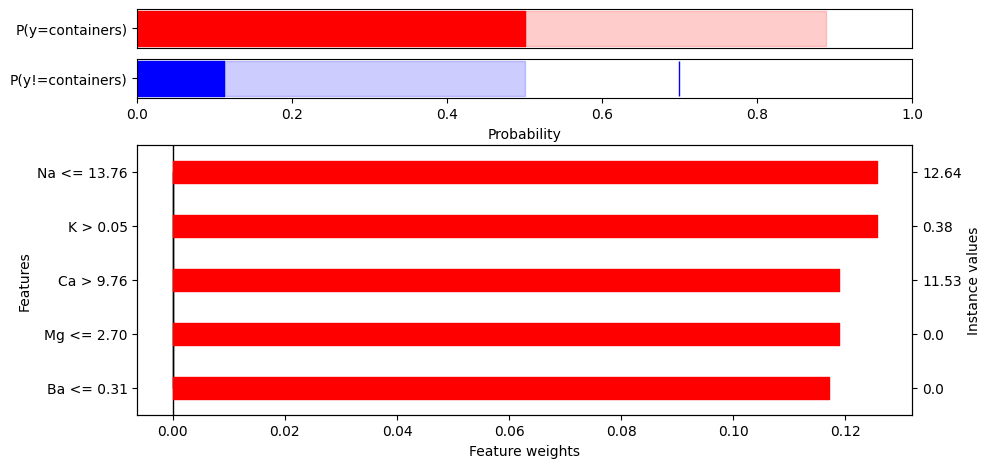

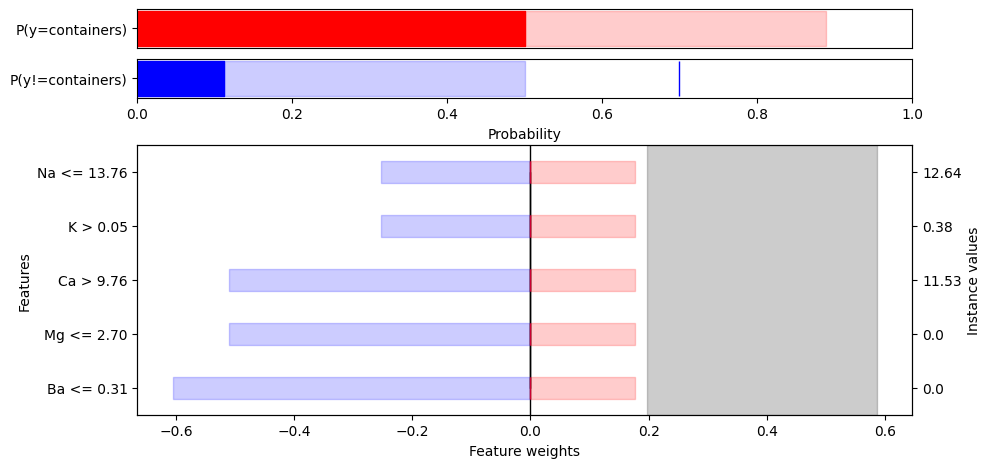

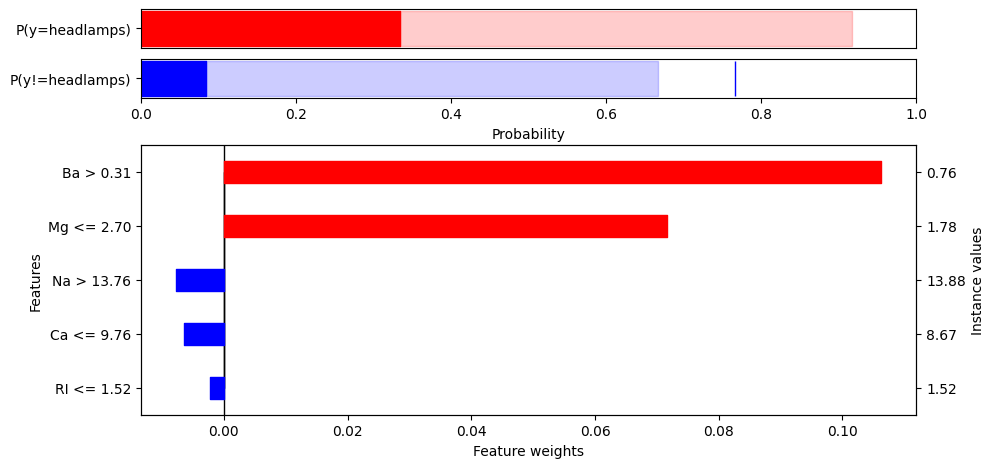

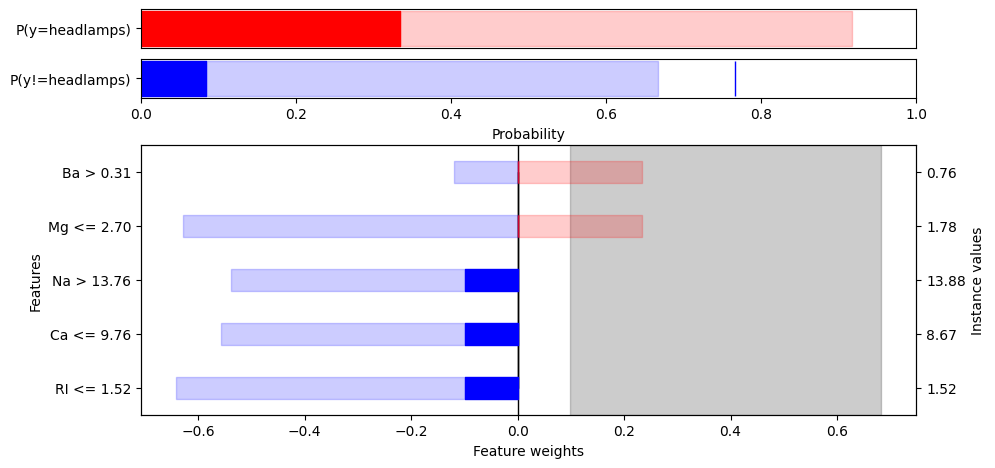

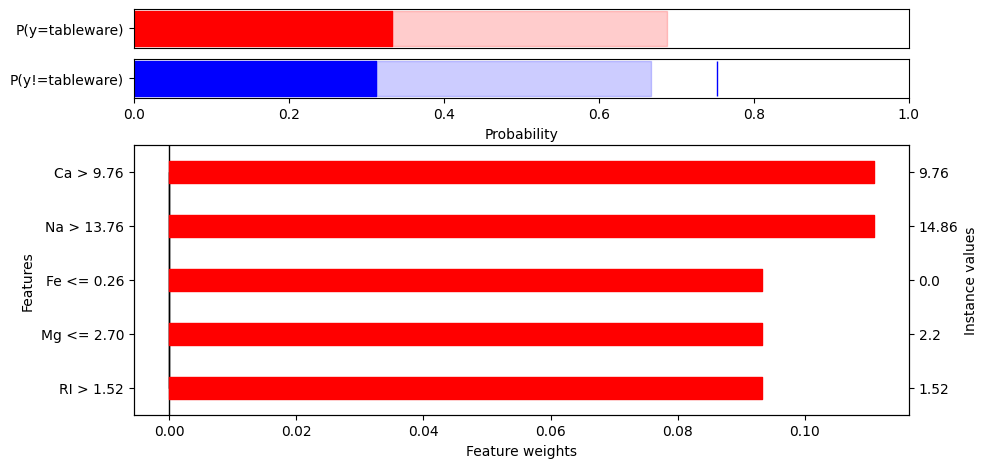

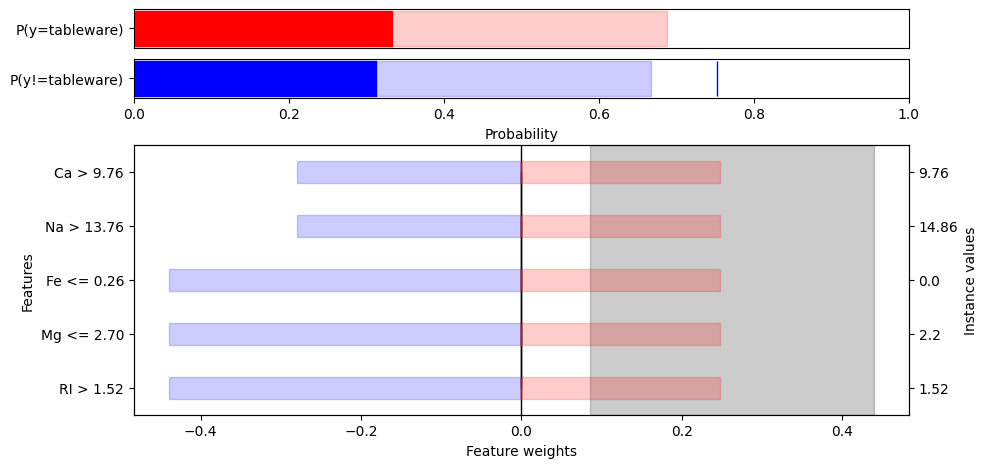

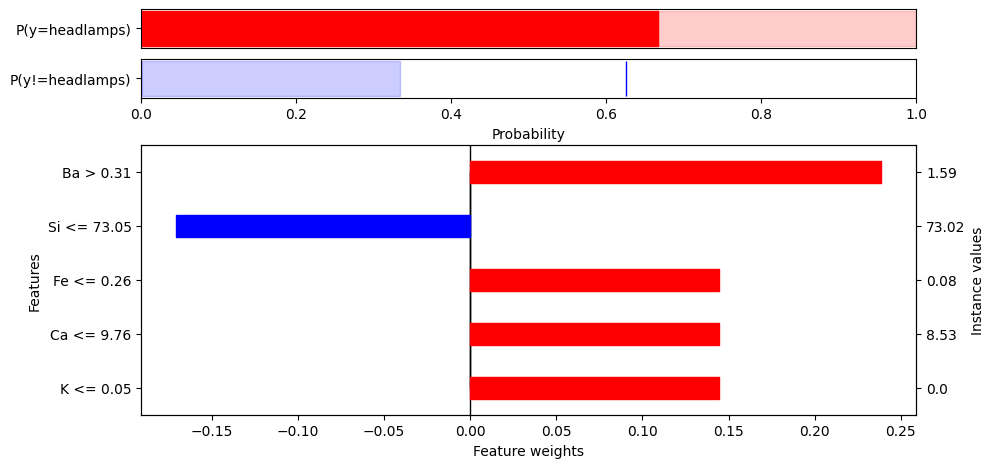

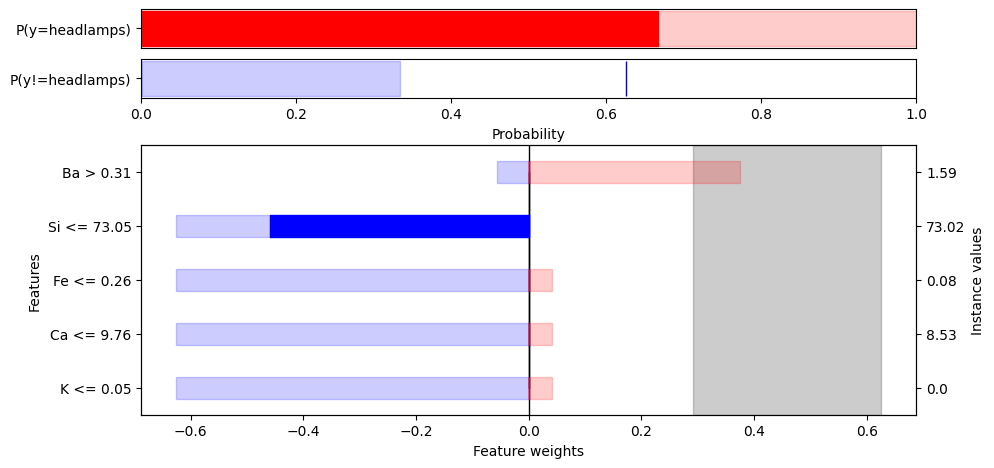

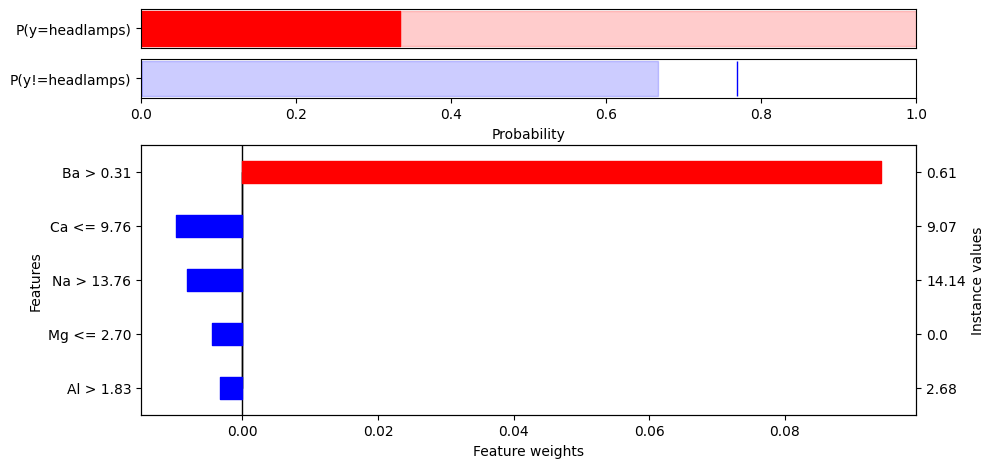

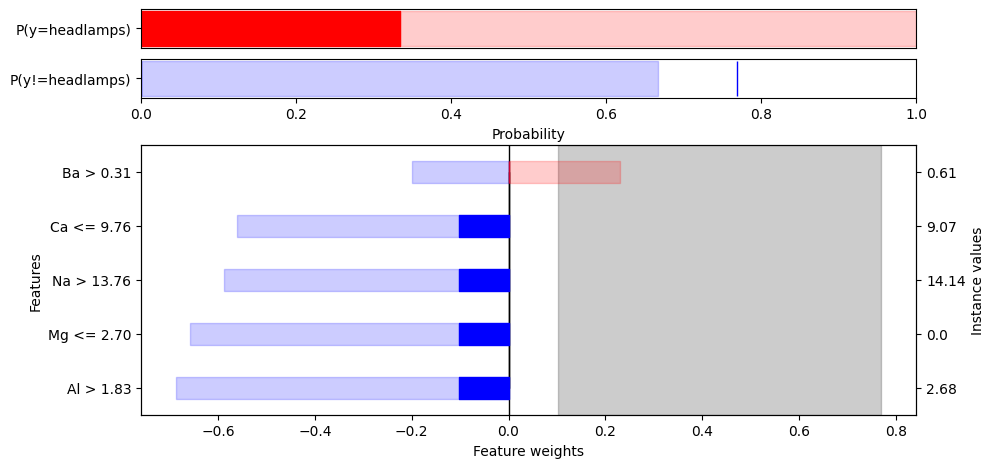

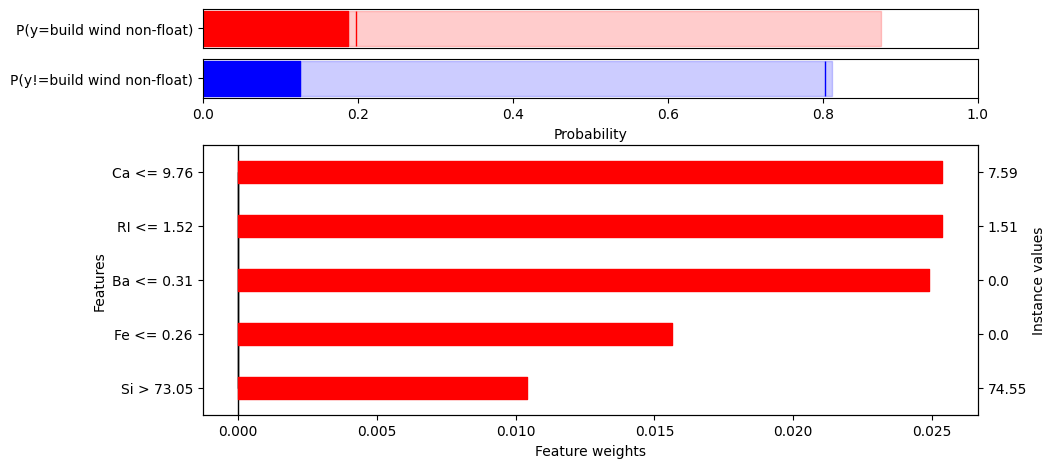

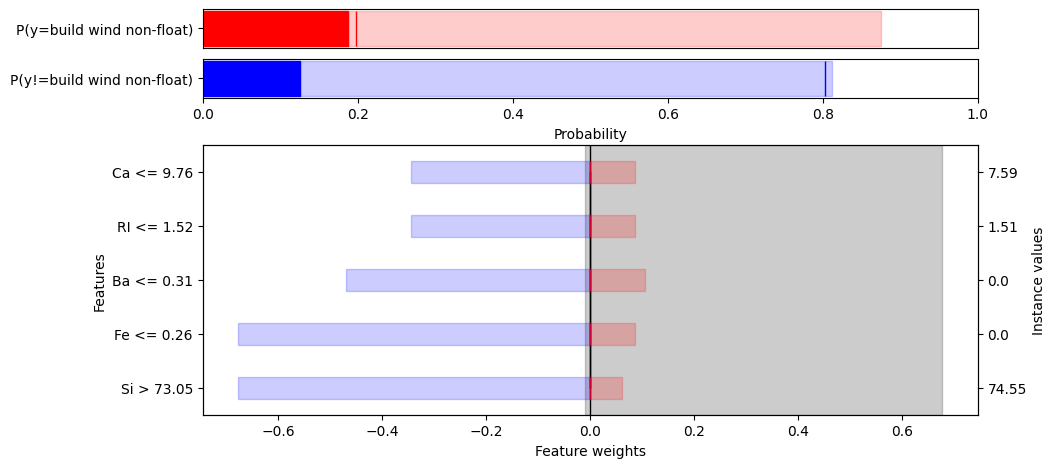

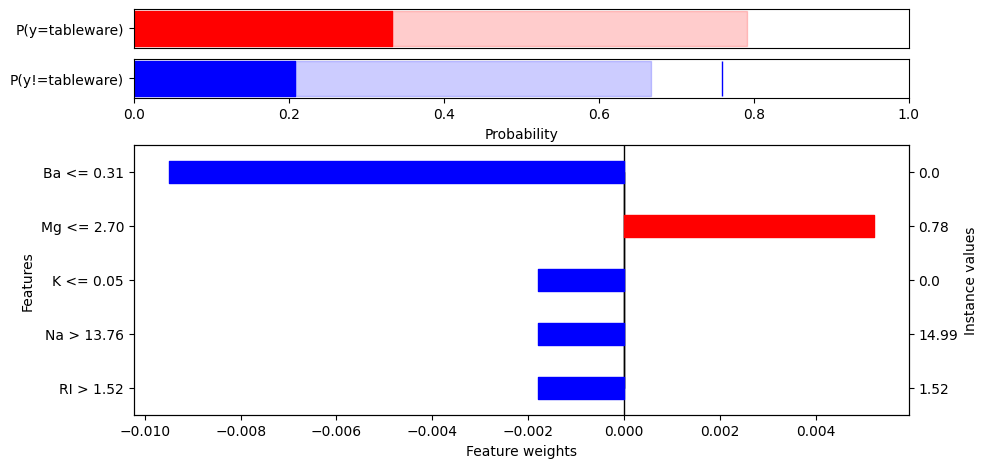

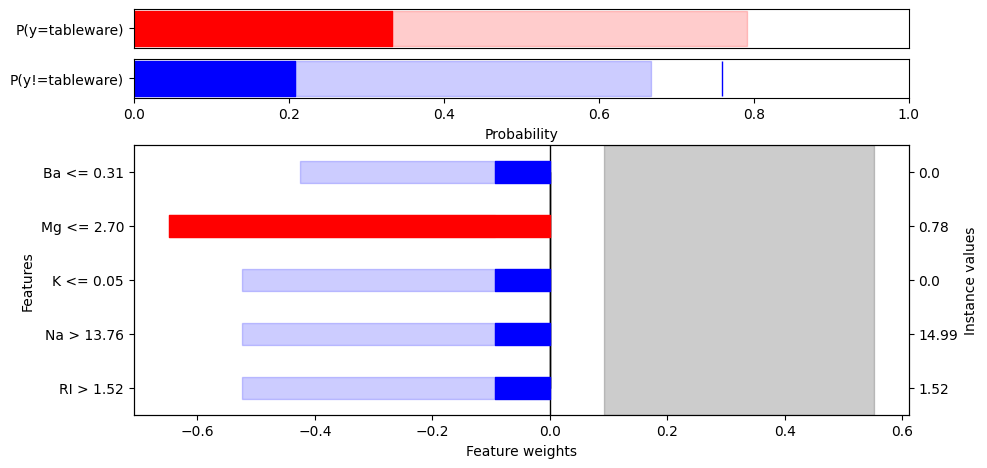

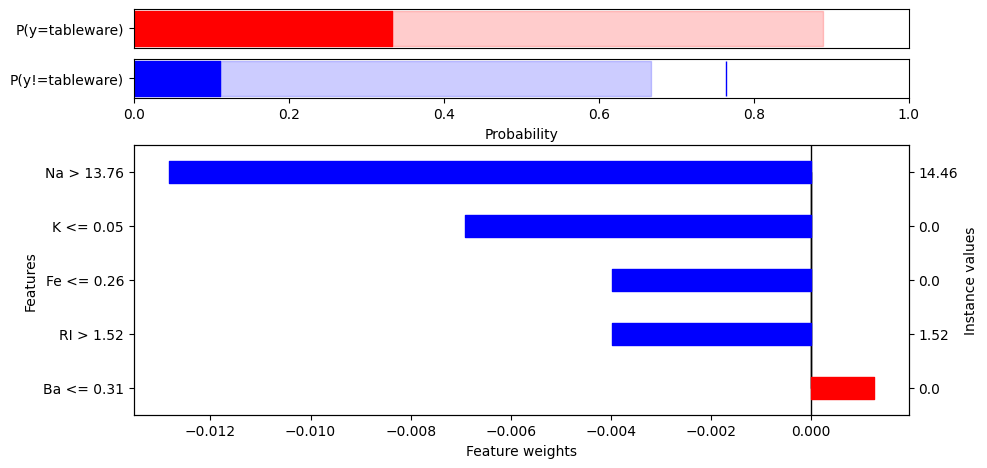

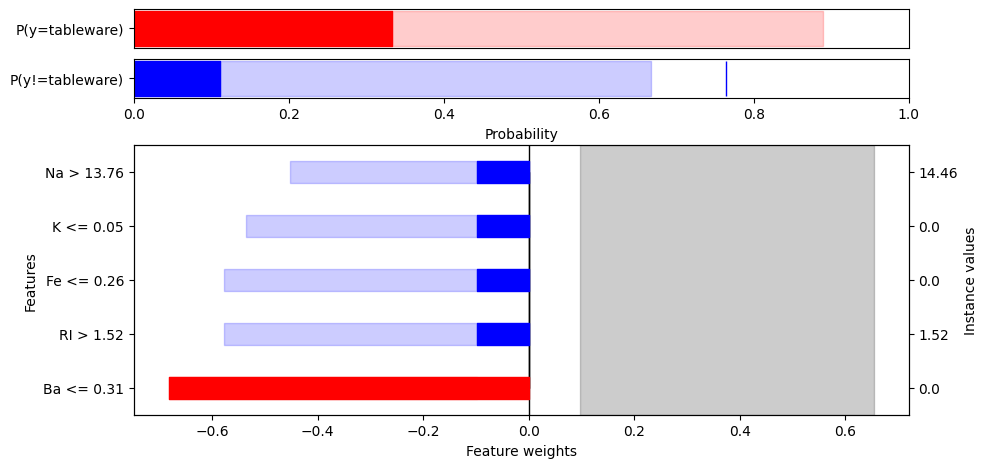

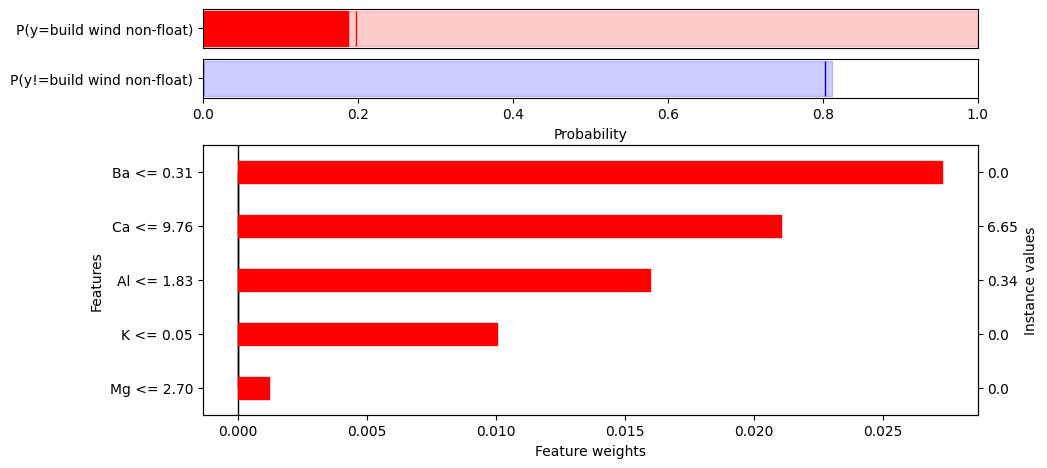

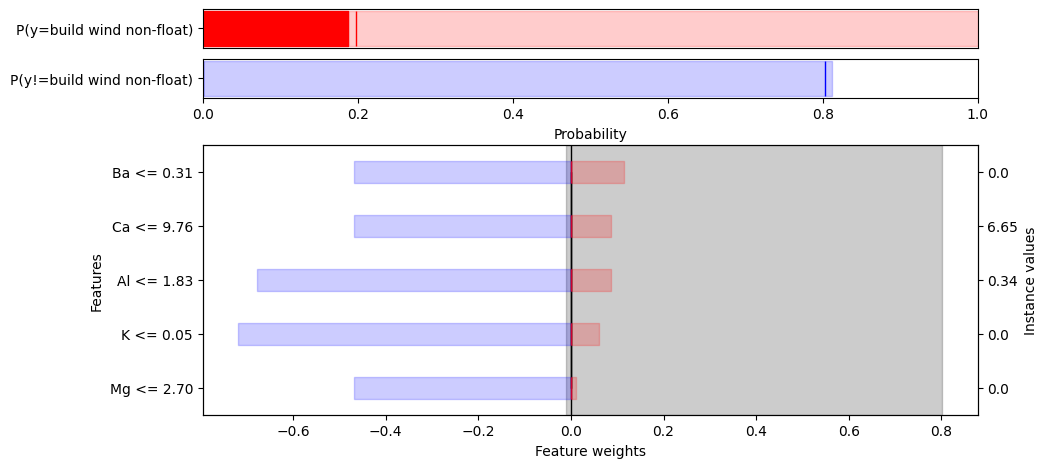

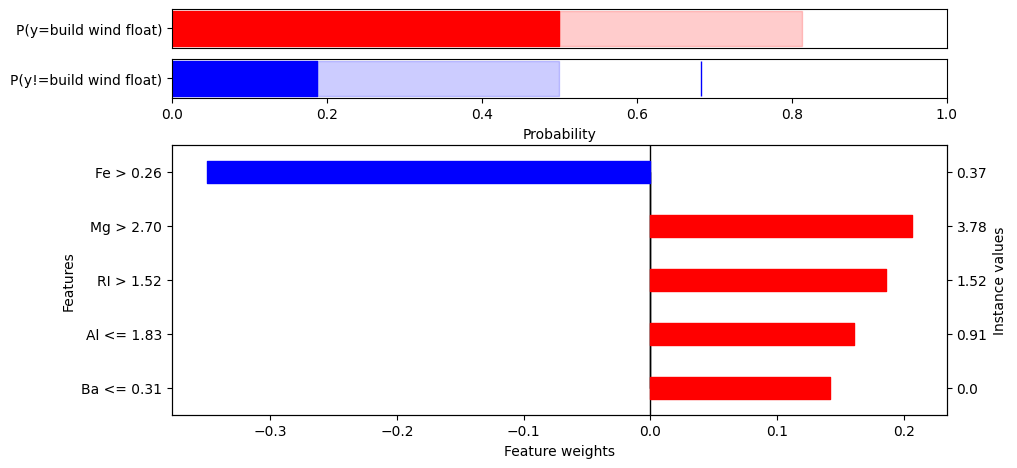

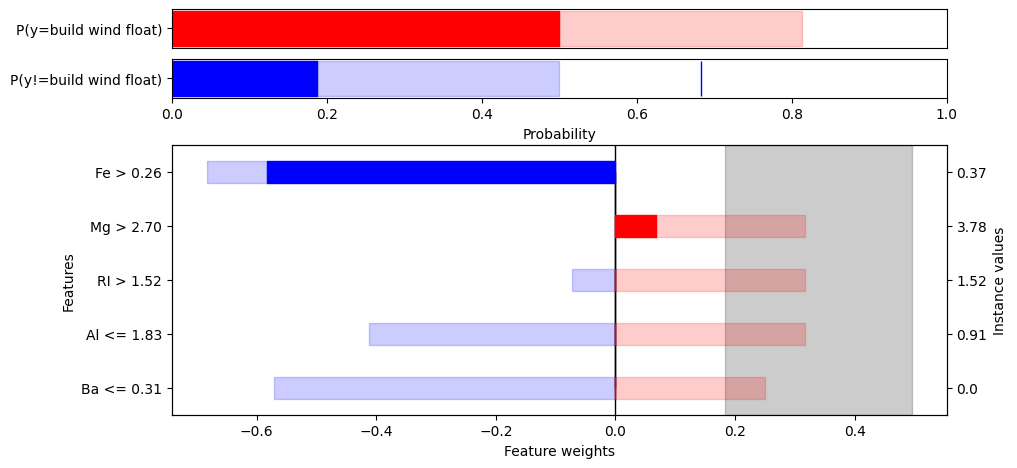

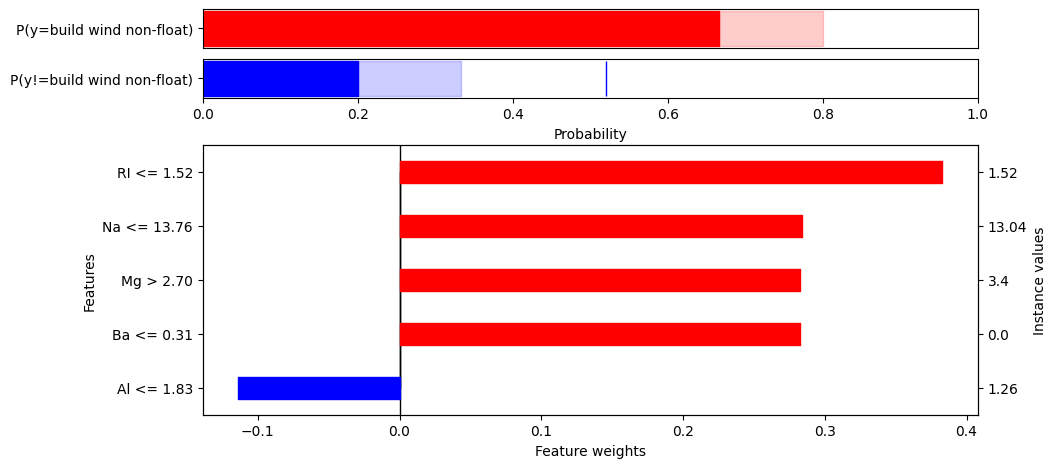

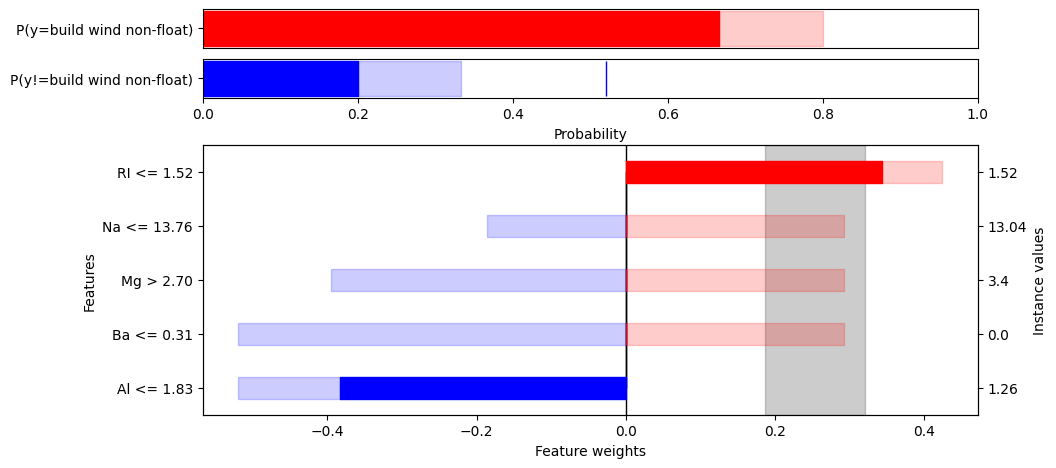

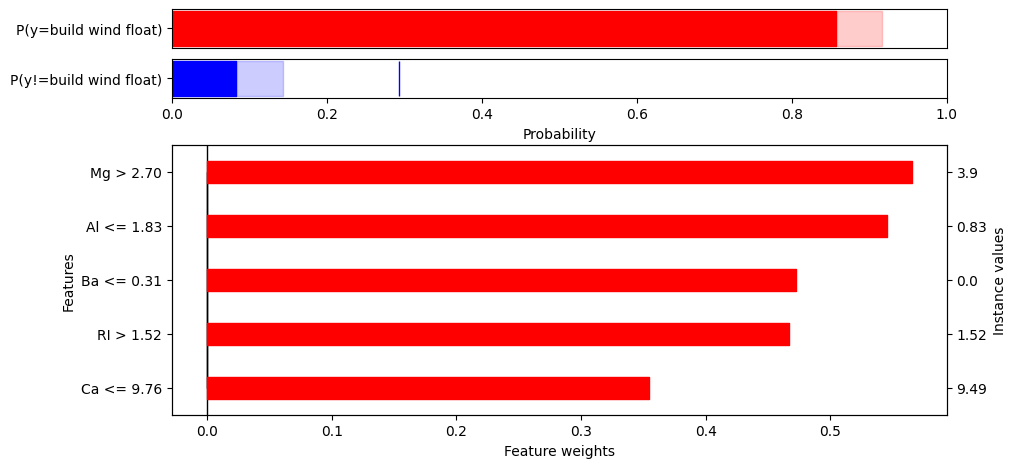

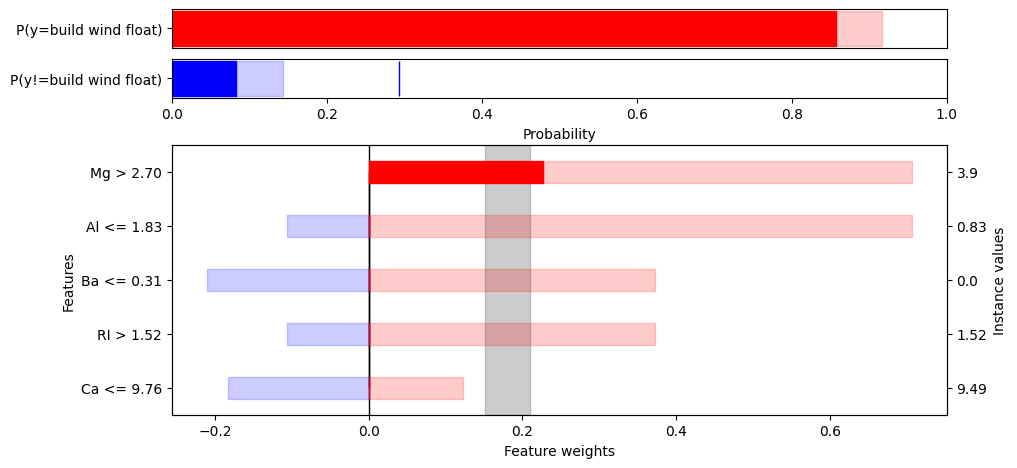

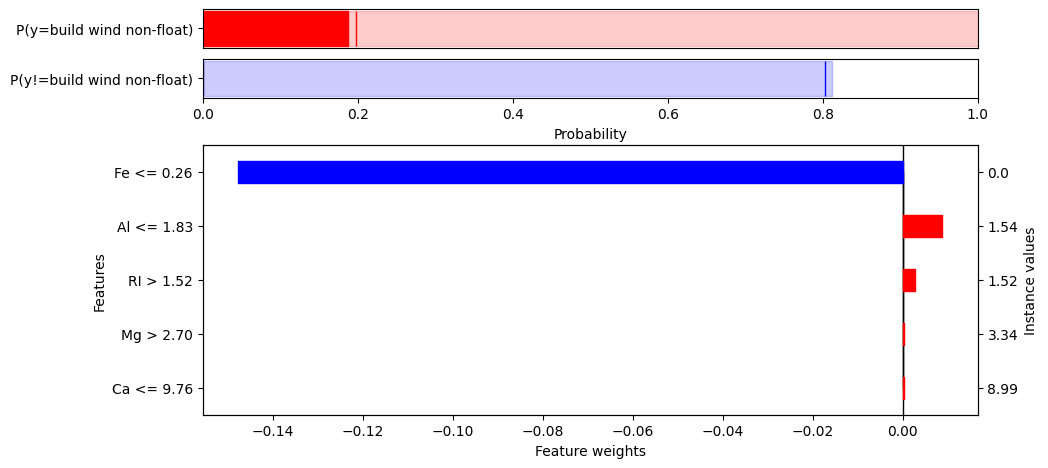

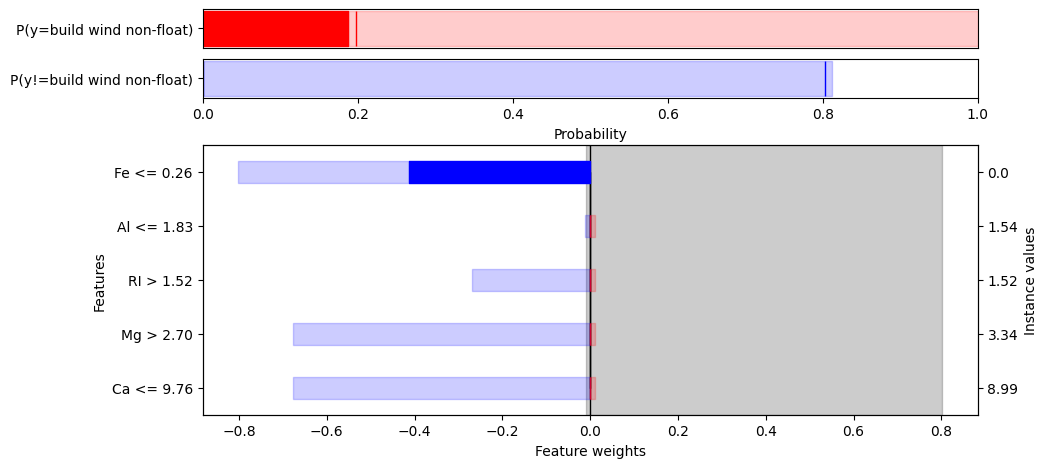

In [24]:
for i in range(num_to_test):
    explanation = factual_explanations[i]
    explanation.plot(
        filter_top=5,
        filename=f"{dataset}_{i}_c{y_test[i]}_p{predicted_classes[i]}_simple_factual.png",
        show=True,
    )
    explanation.plot(
        uncertainty=True,
        filter_top=5,
        filename=f"{dataset}_{i}_c{y_test[i]}_p{predicted_classes[i]}_simple_factual_uncertainty.png",
        show=True,
    )

In [25]:
alternative_explanations = ce.explore_alternatives(x_test)

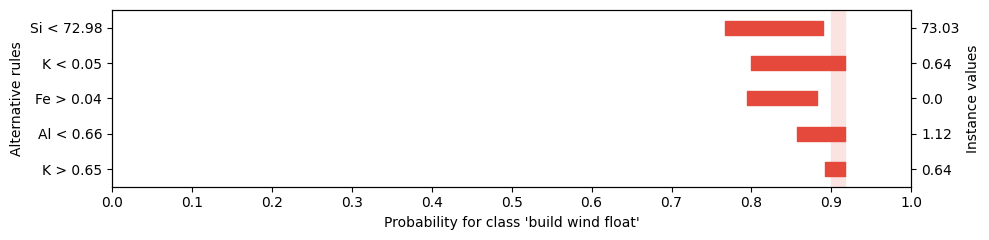

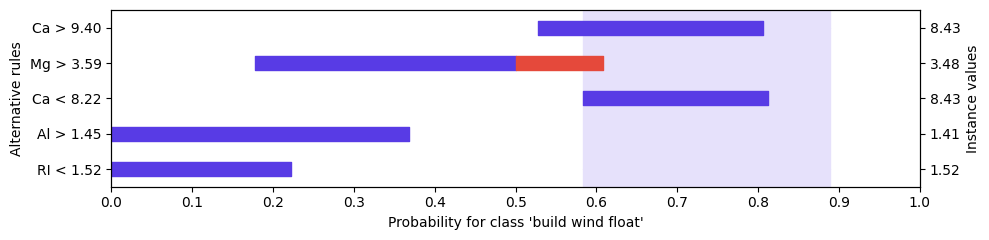

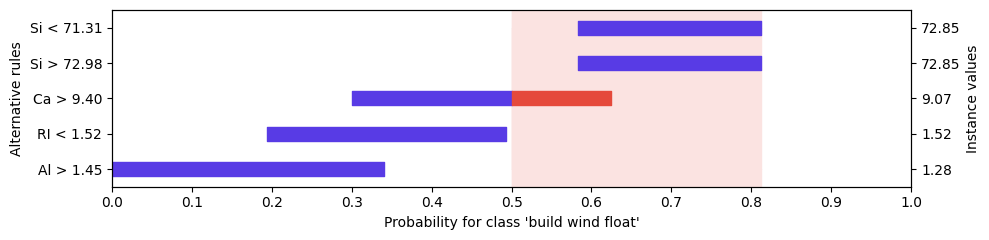

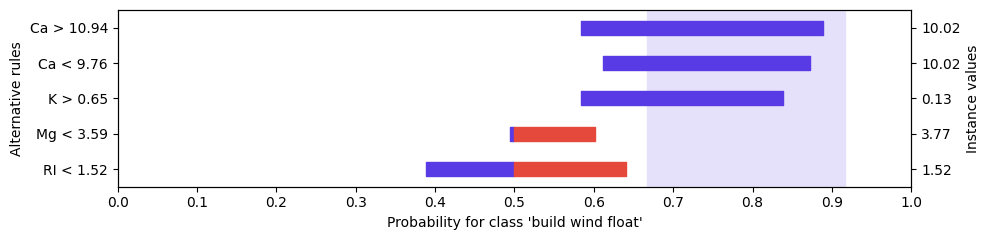

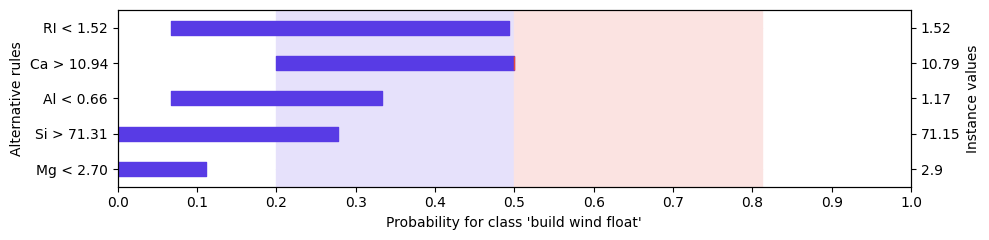

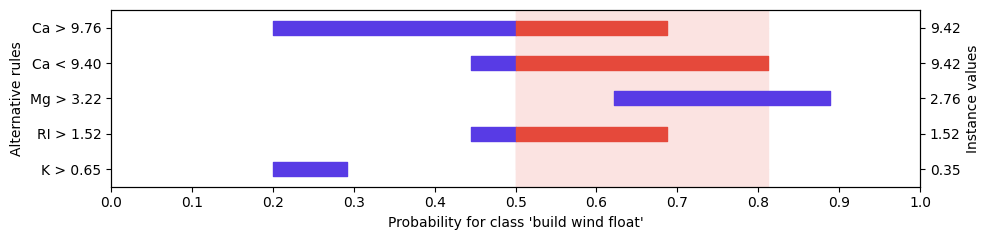

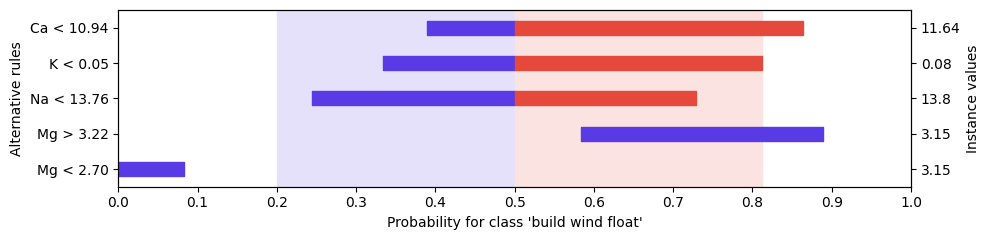

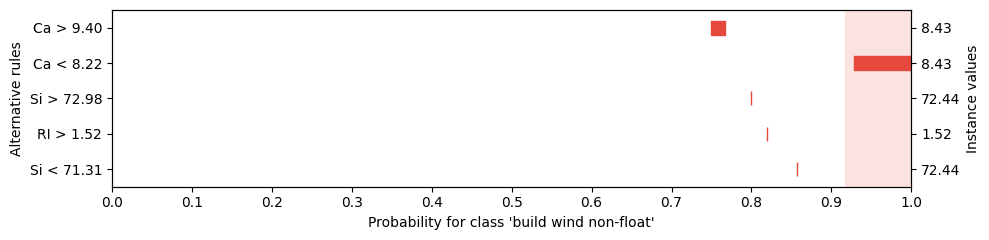

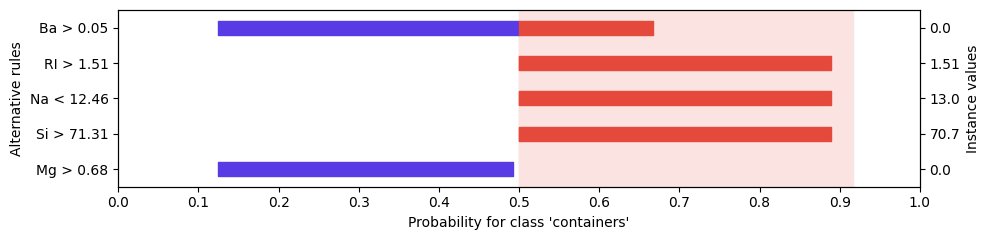

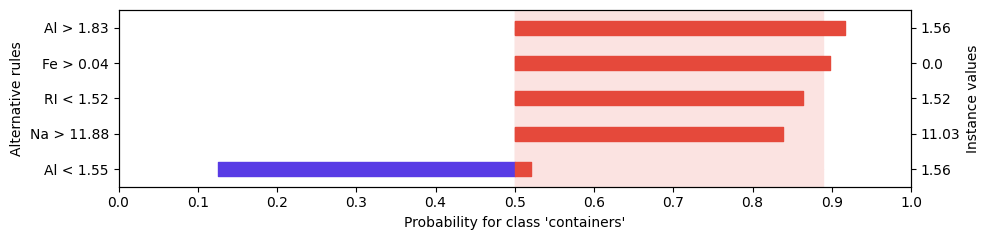

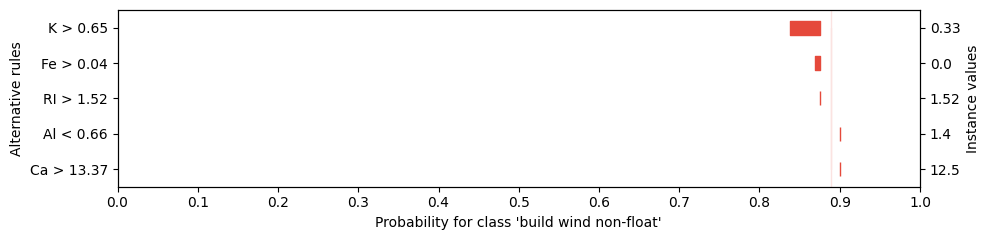

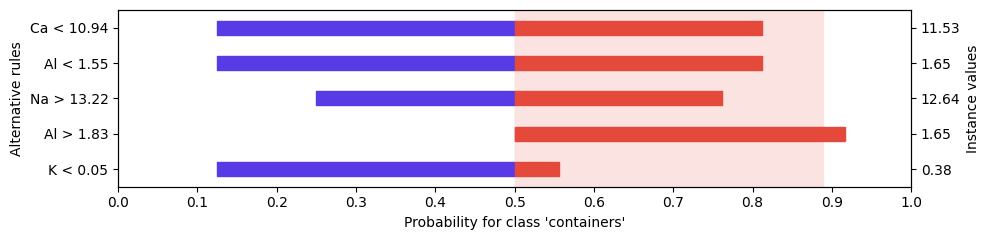

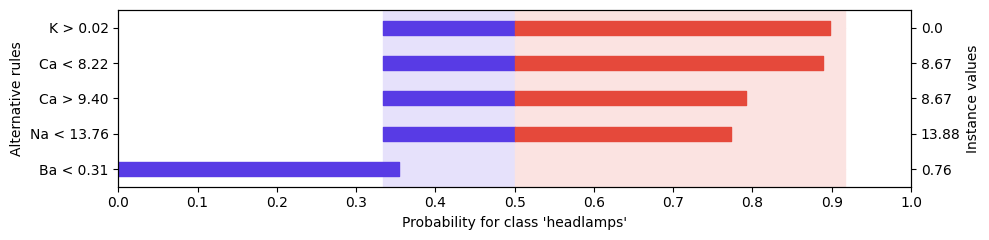

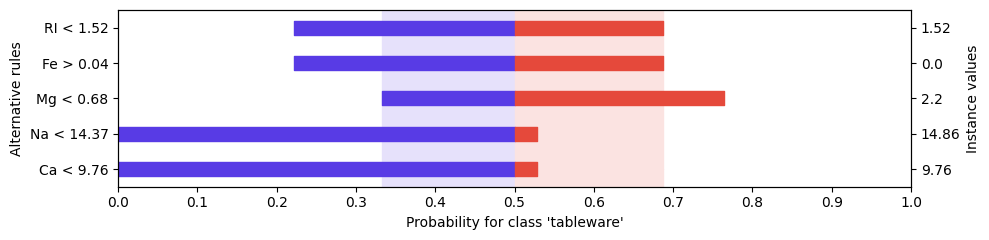

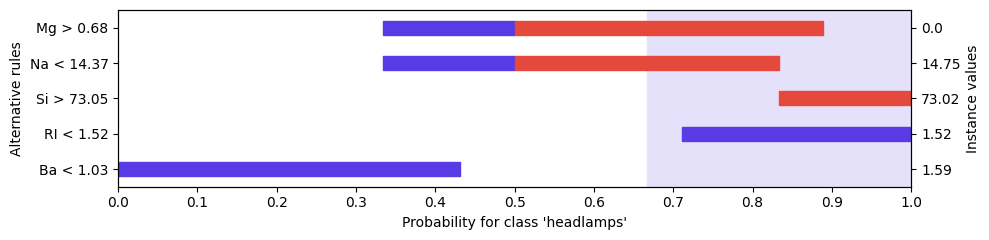

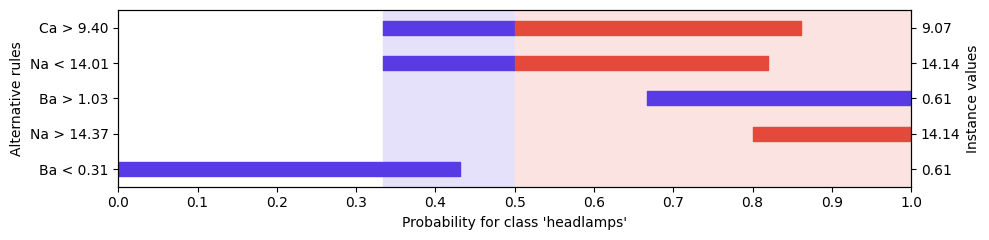

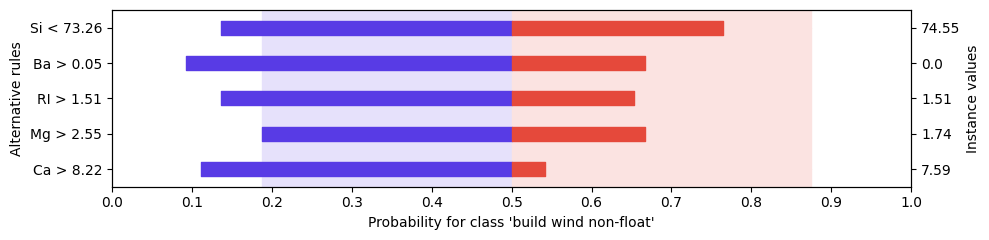

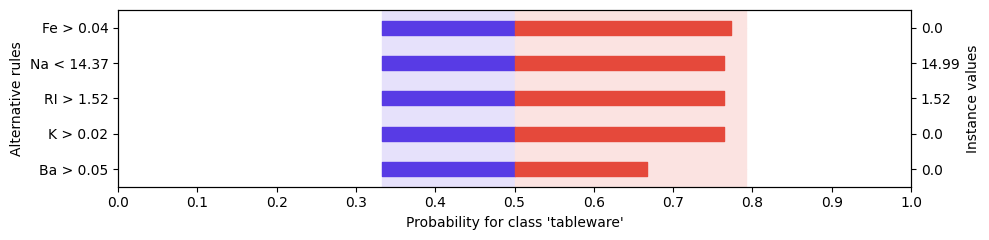

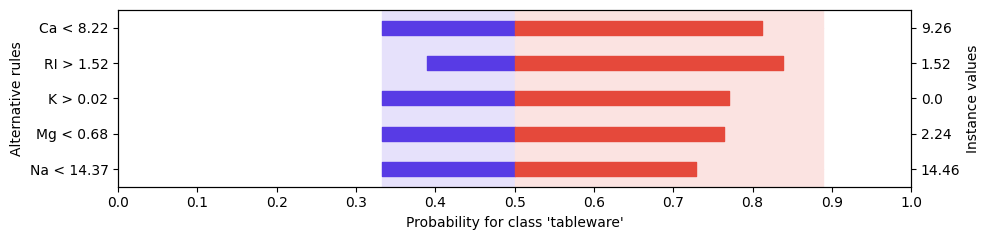

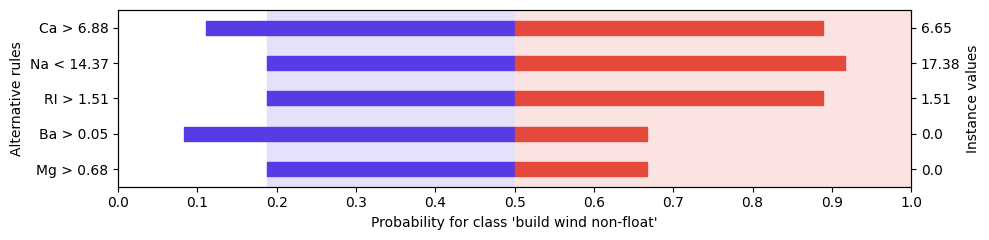

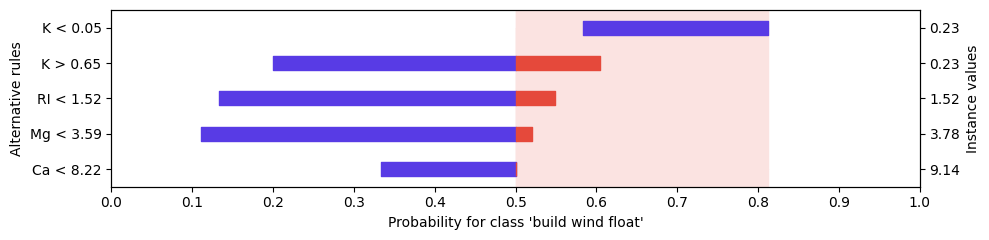

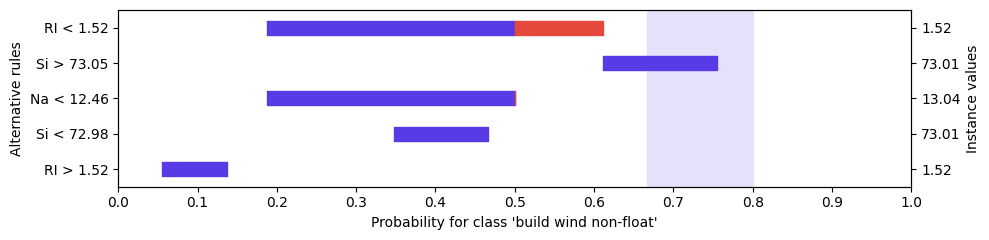

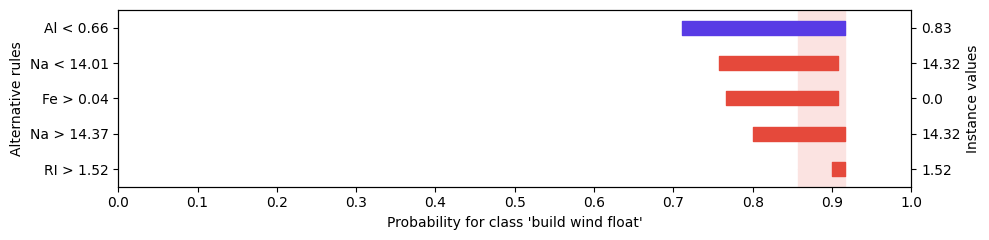

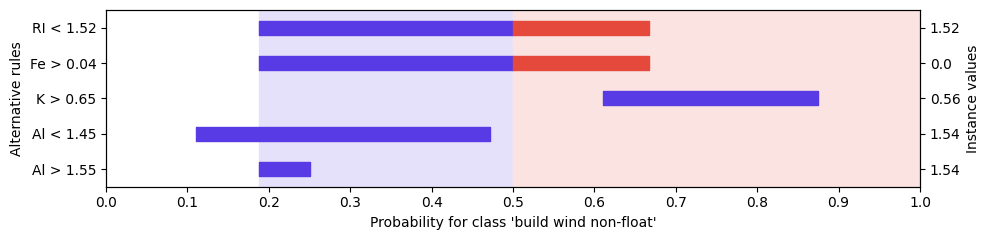

In [26]:
for i in range(num_to_test):
    explanation = alternative_explanations[i]
    explanation.plot(
        filter_top=5,
        filename=f"{dataset}_{i}_c{y_test[i]}_p{predicted_classes[i]}_simple_alternative.png",
        show=True,
    )

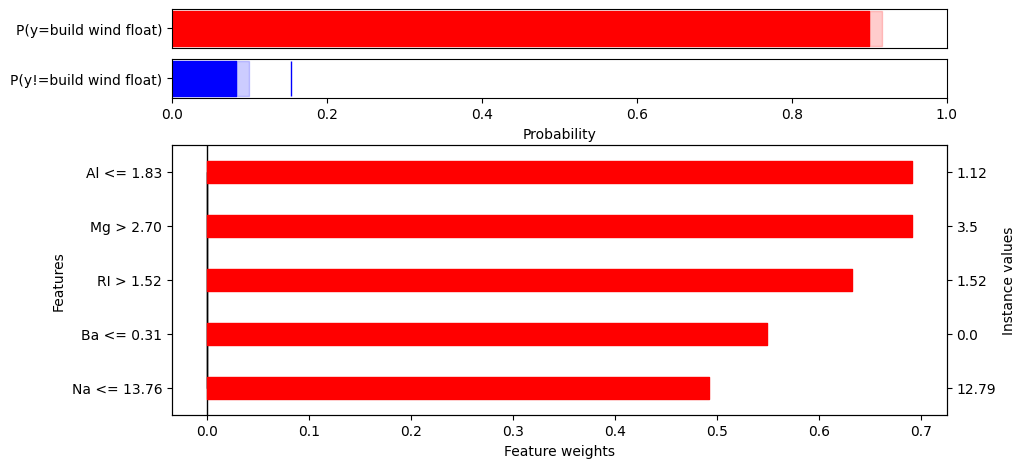

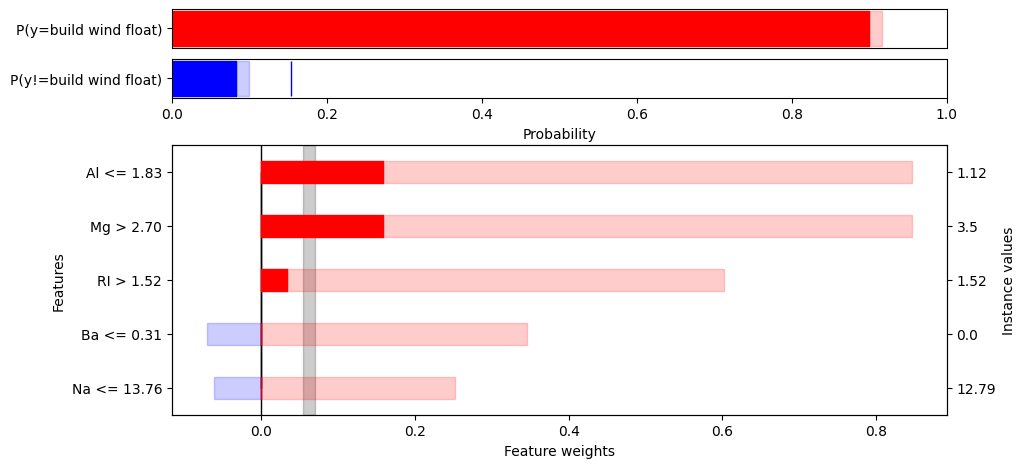

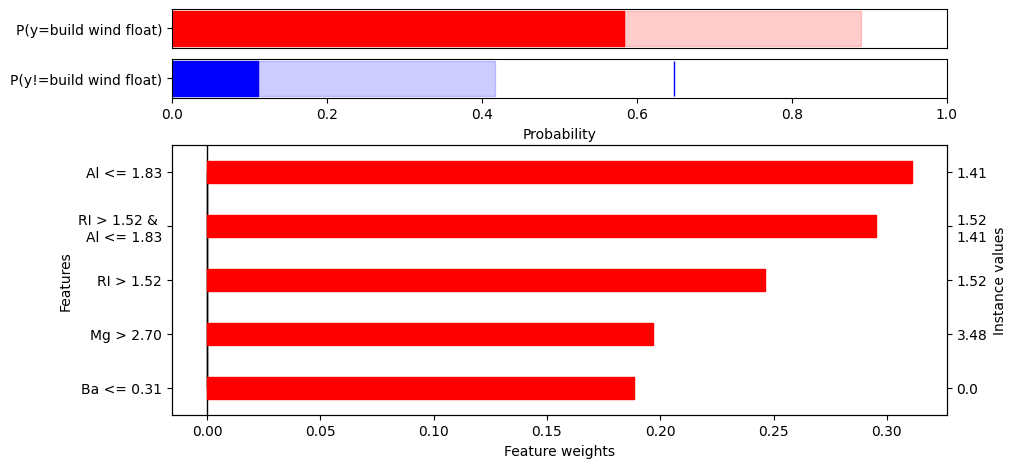

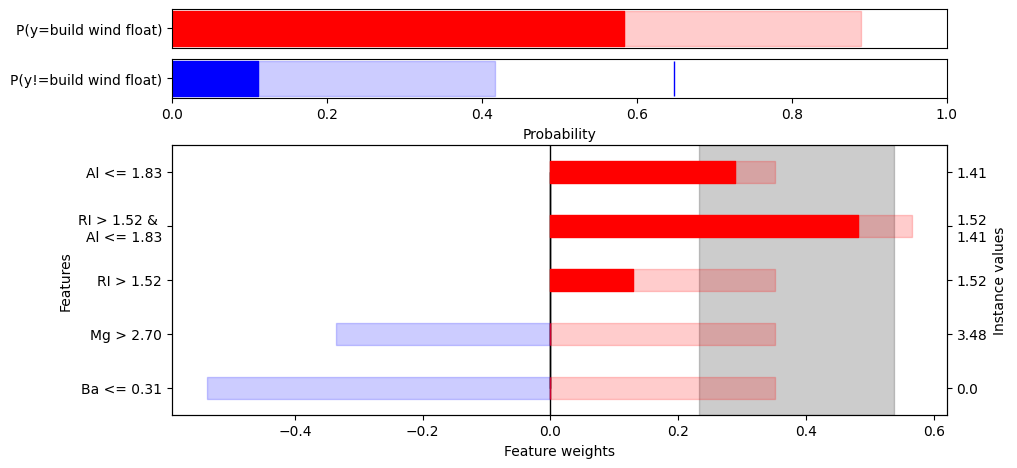

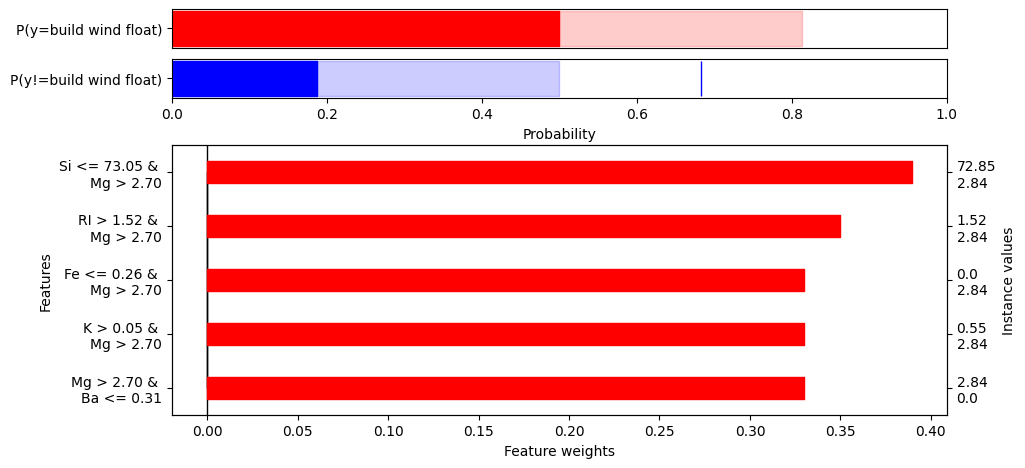

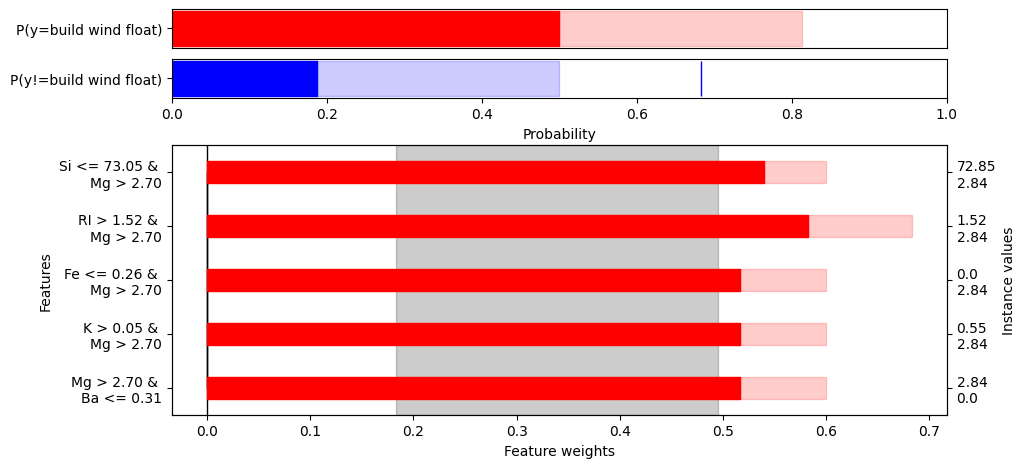

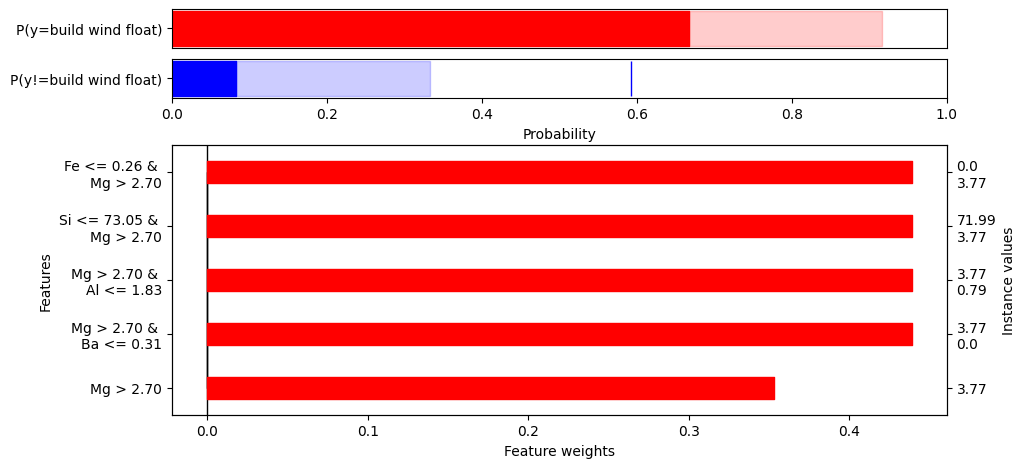

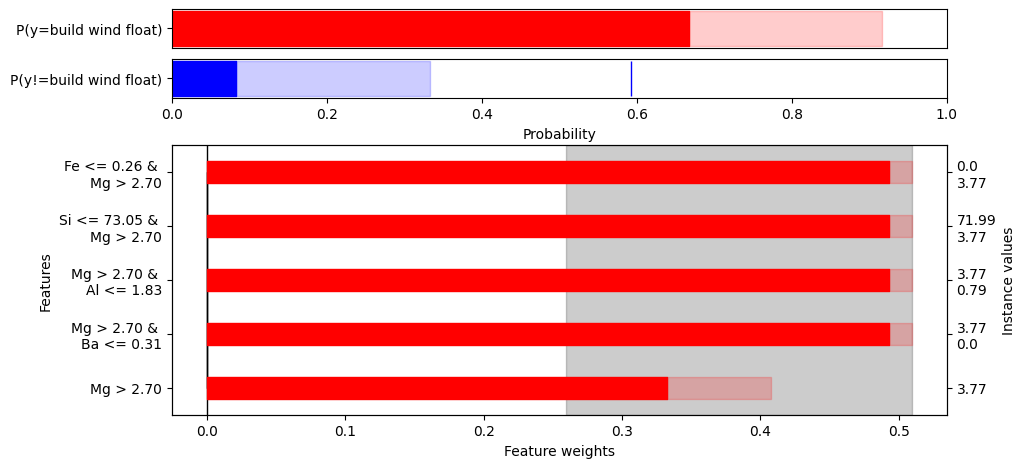

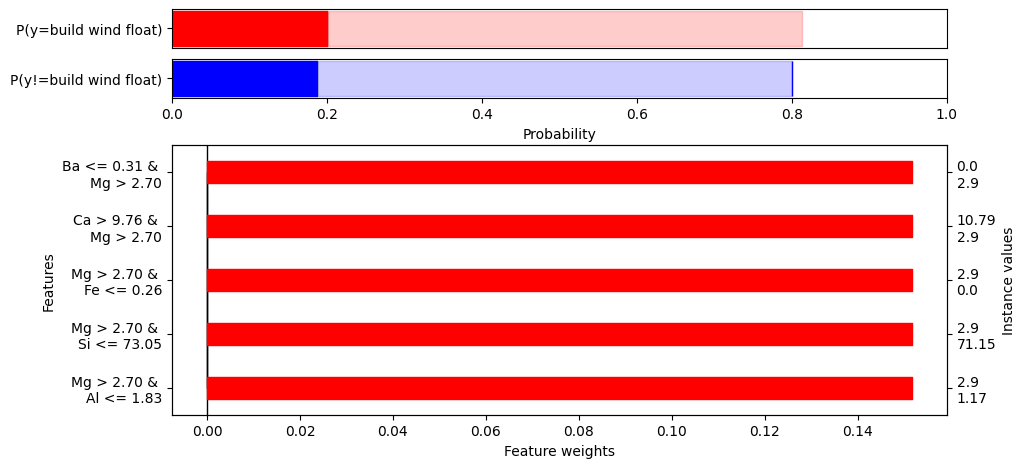

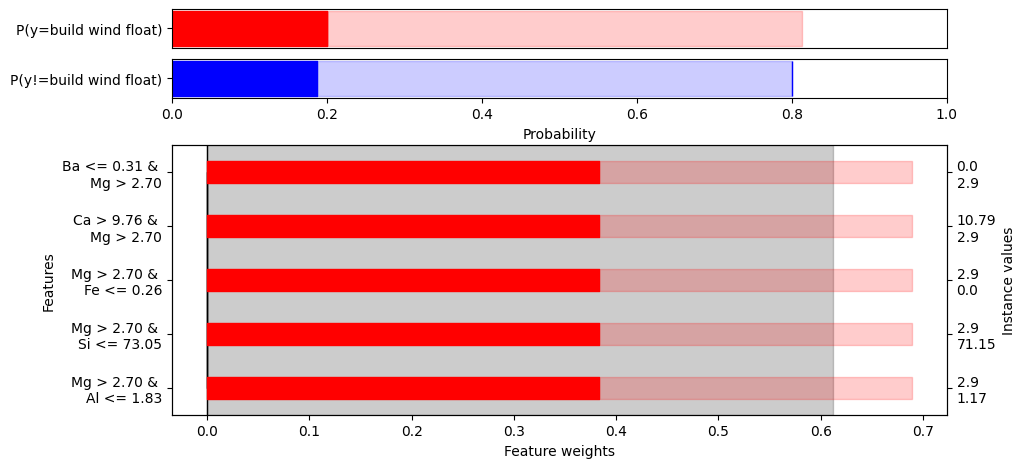

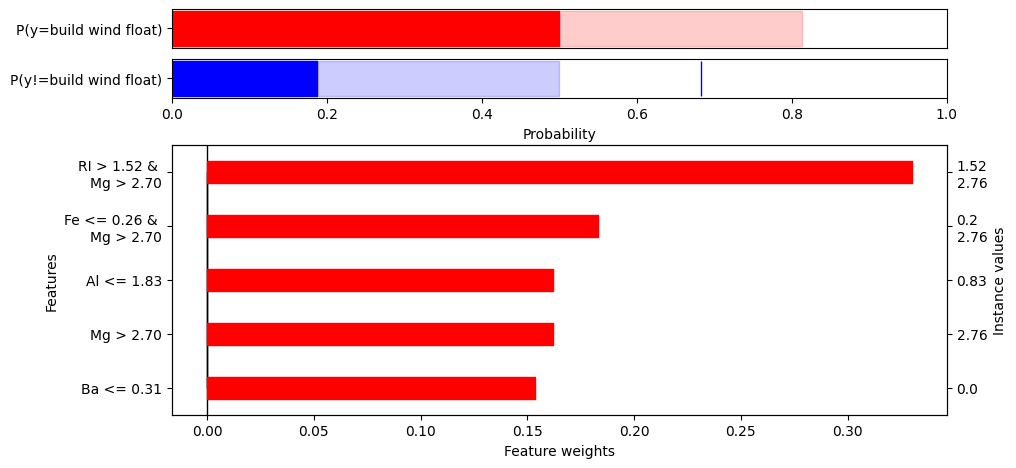

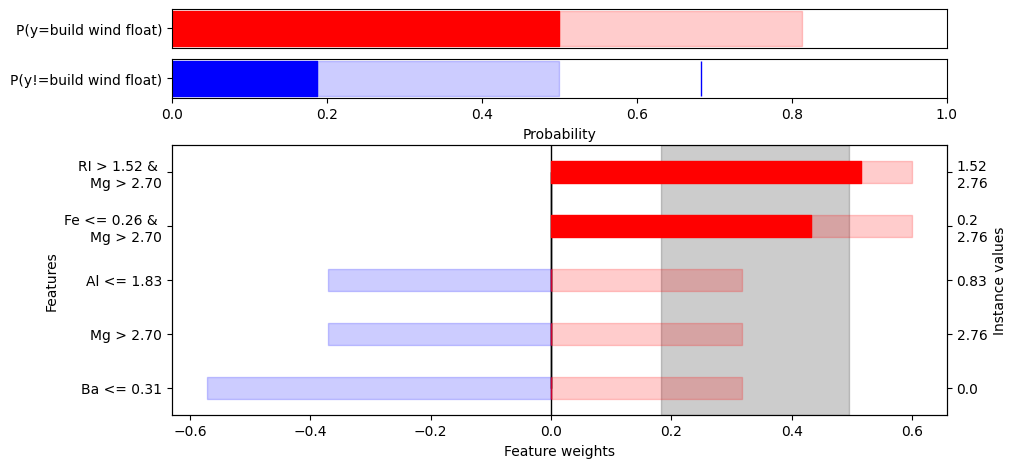

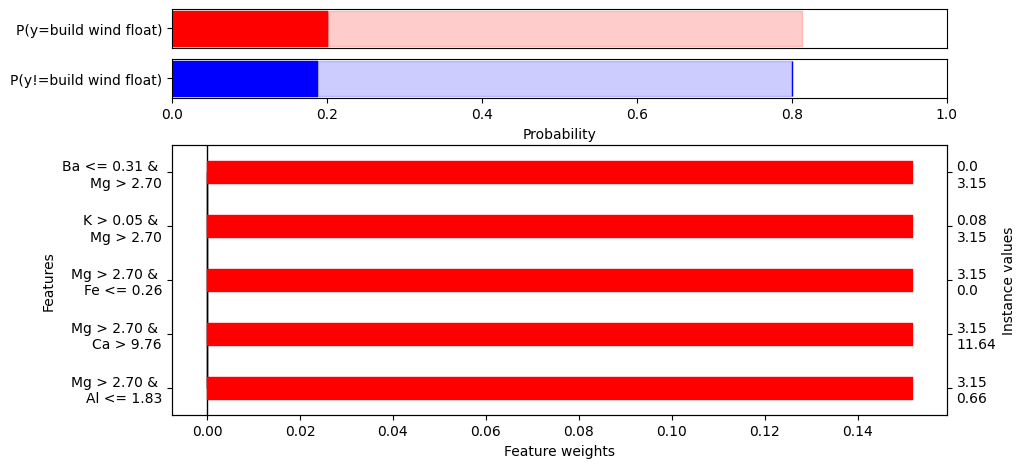

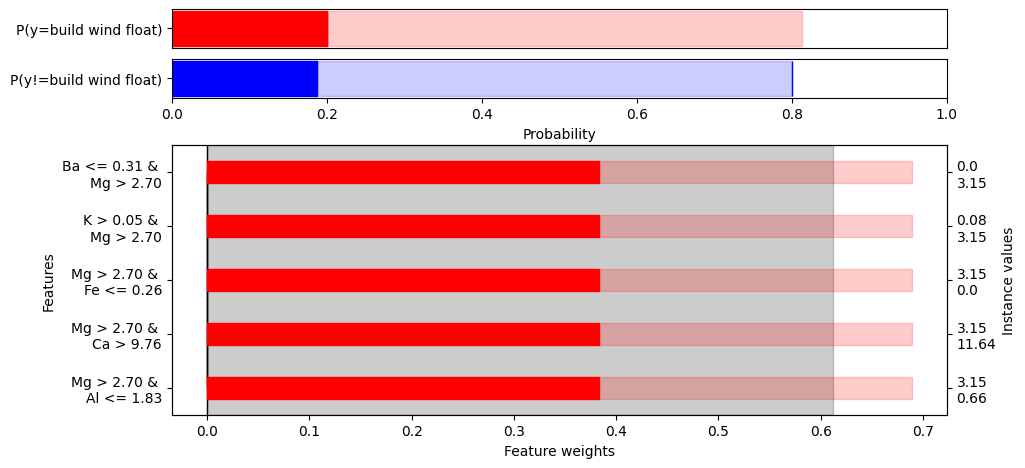

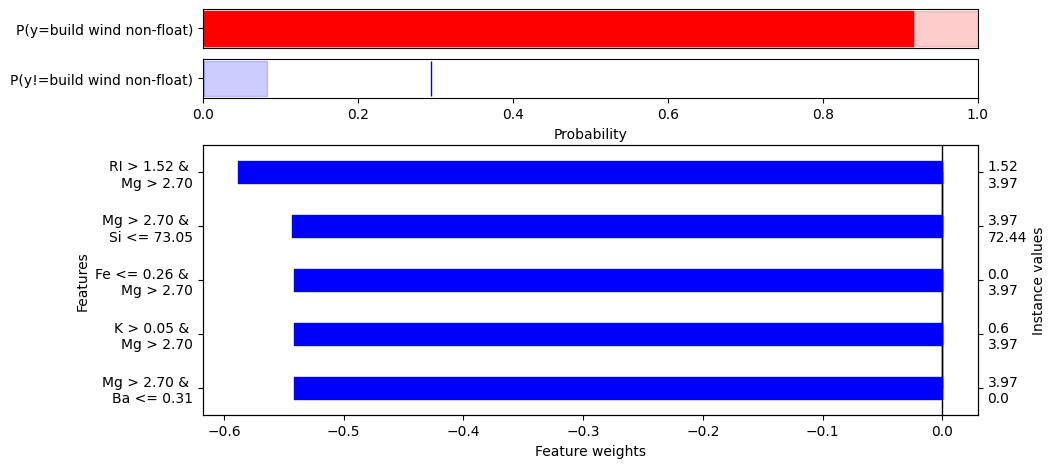

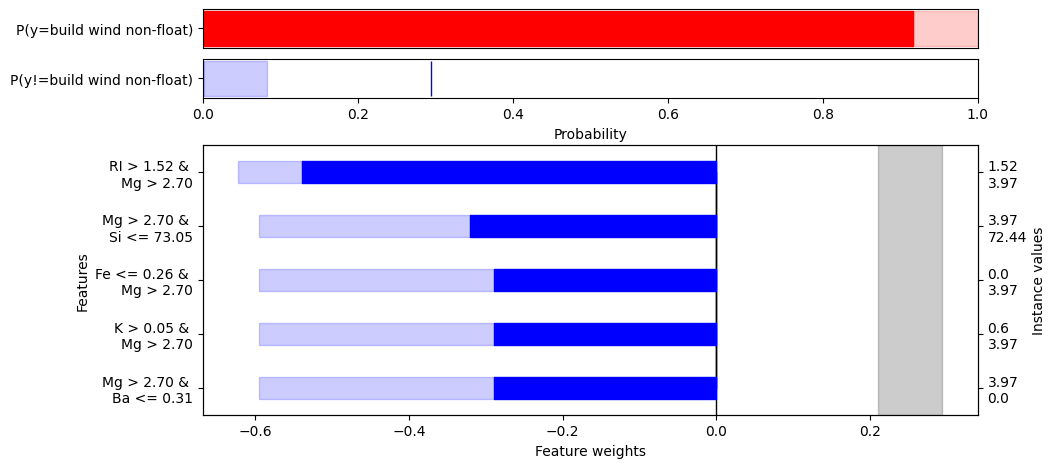

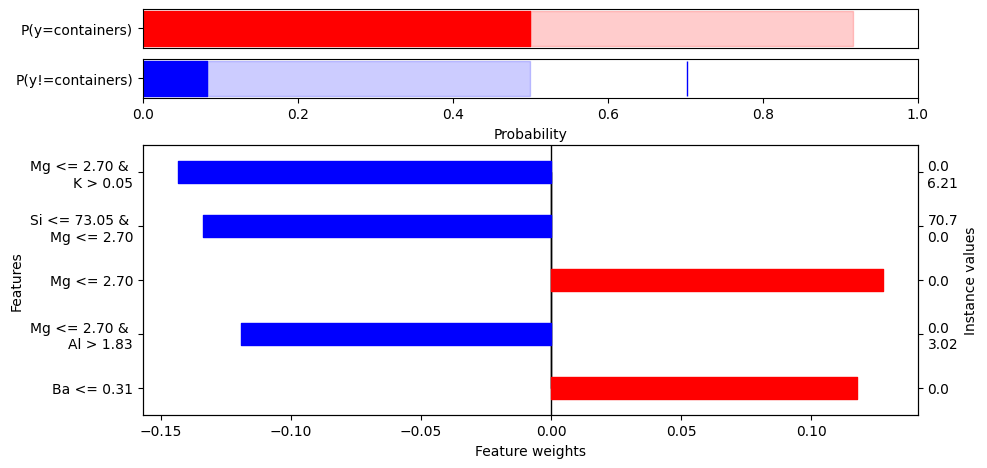

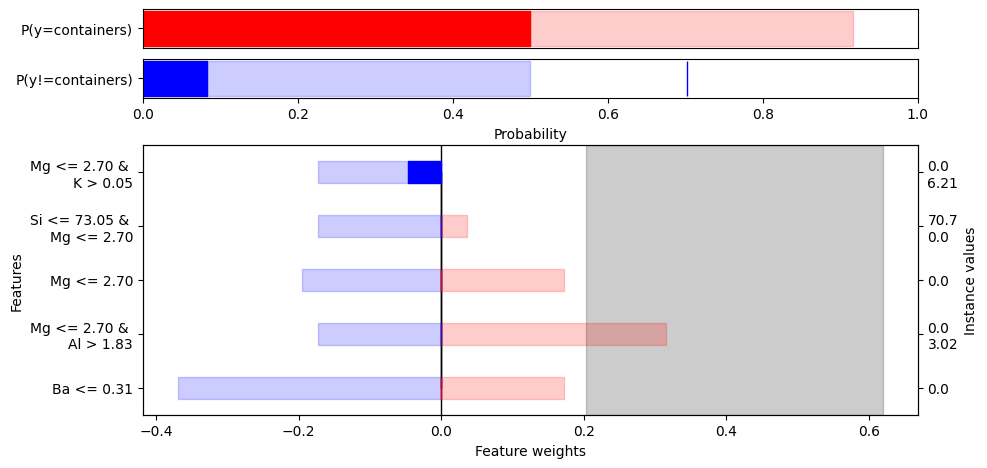

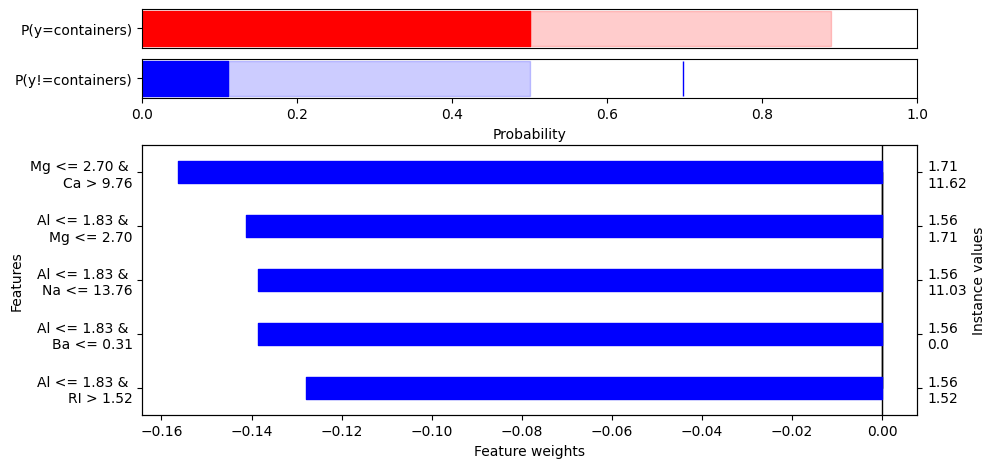

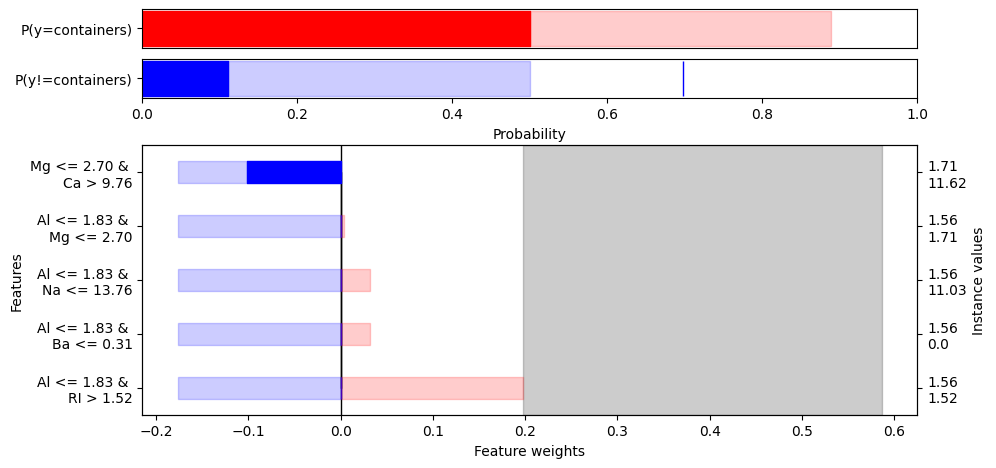

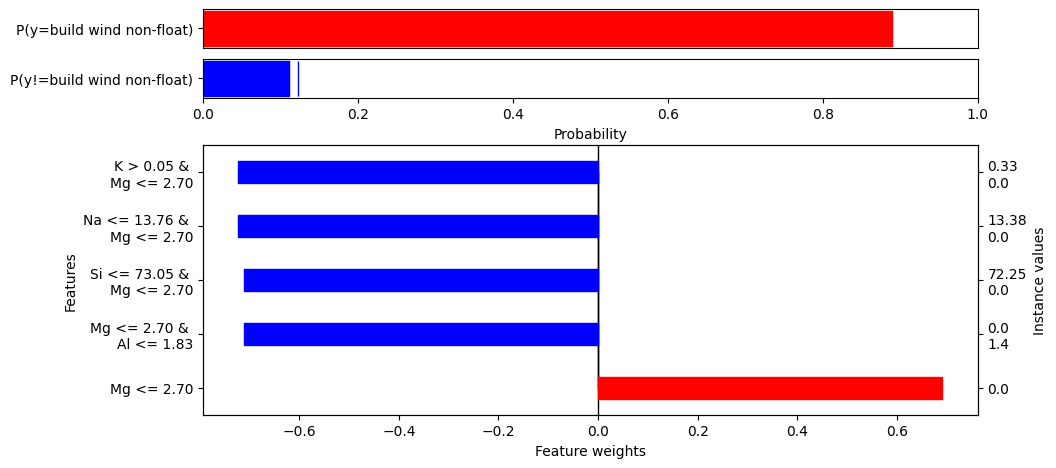

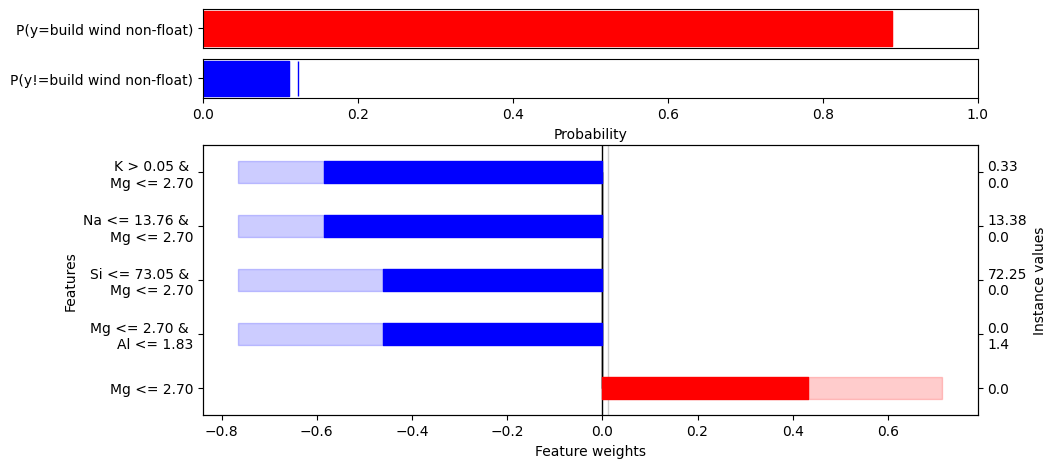

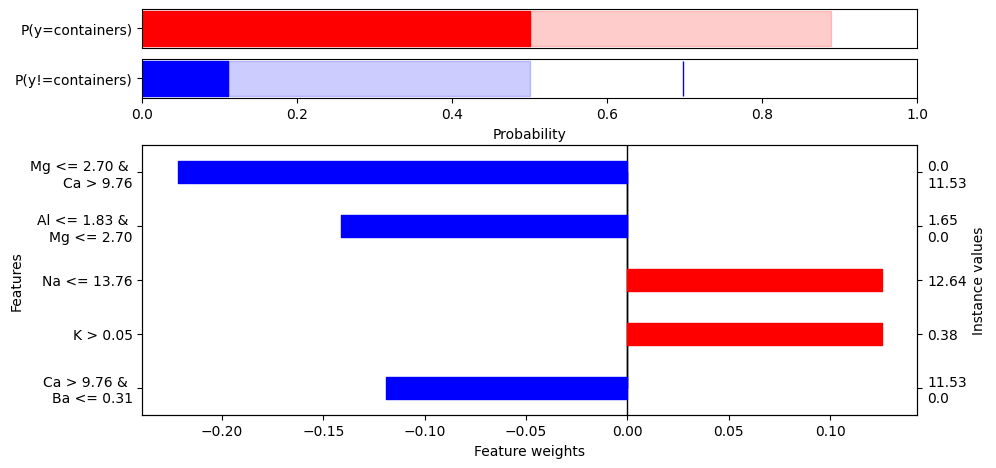

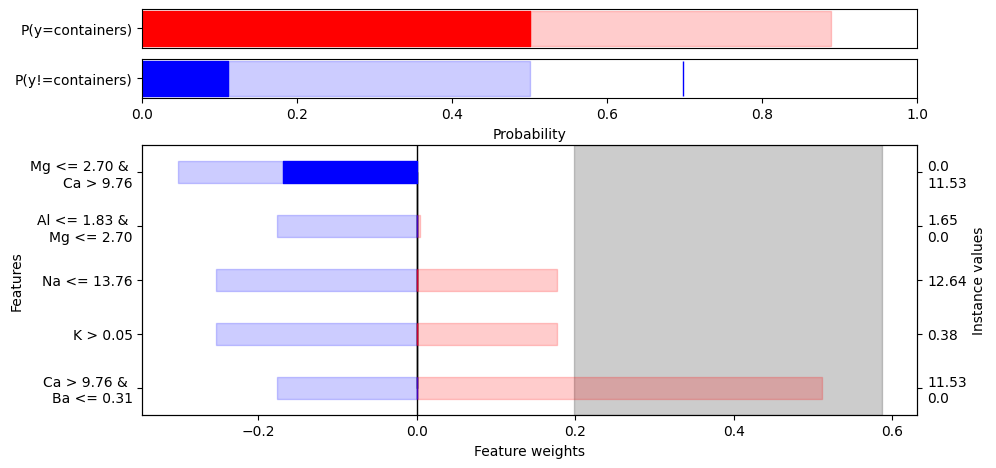

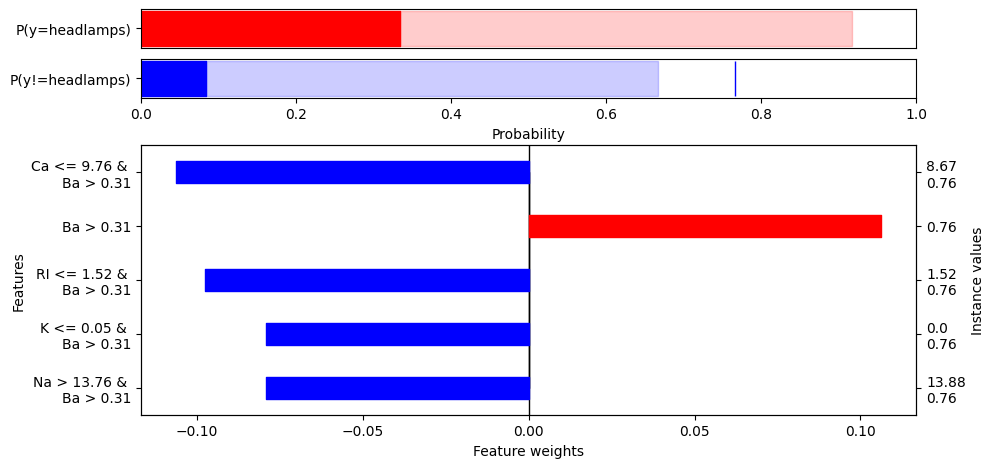

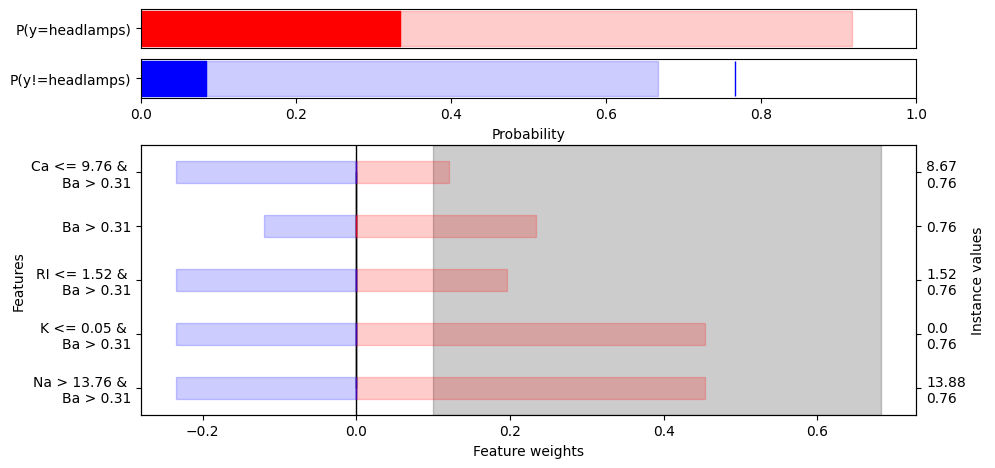

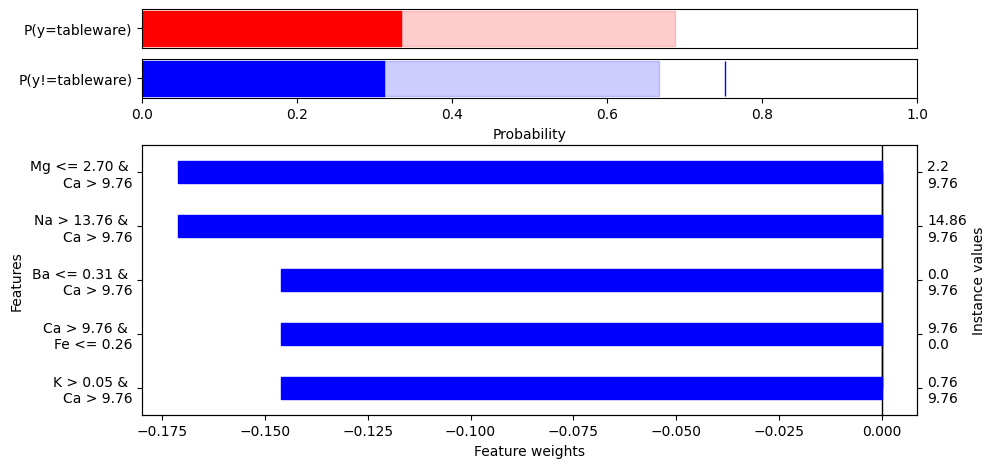

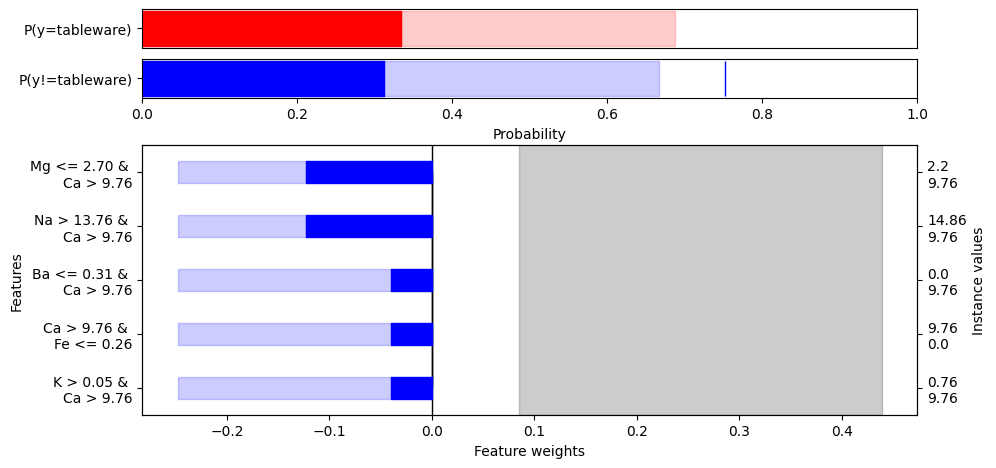

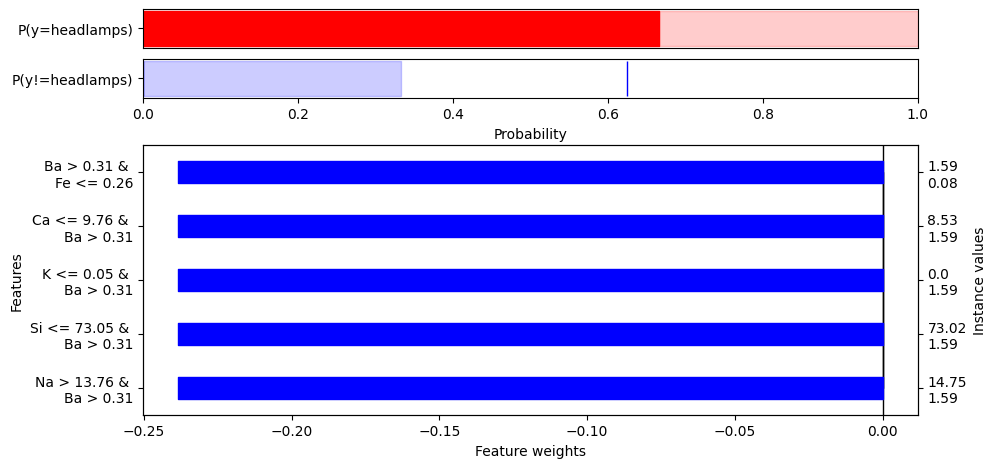

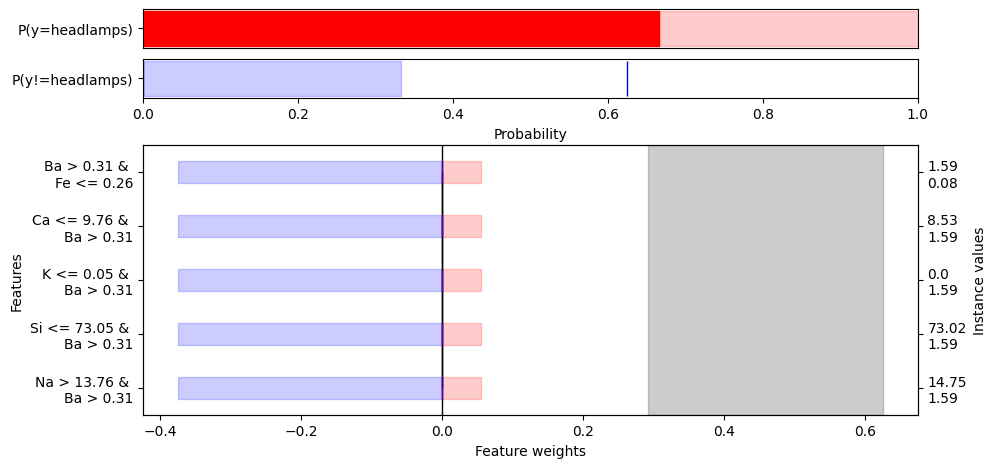

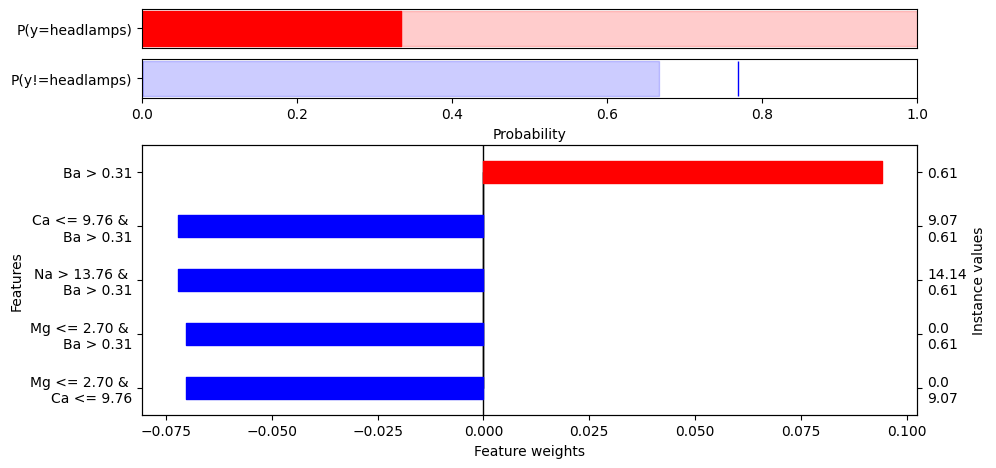

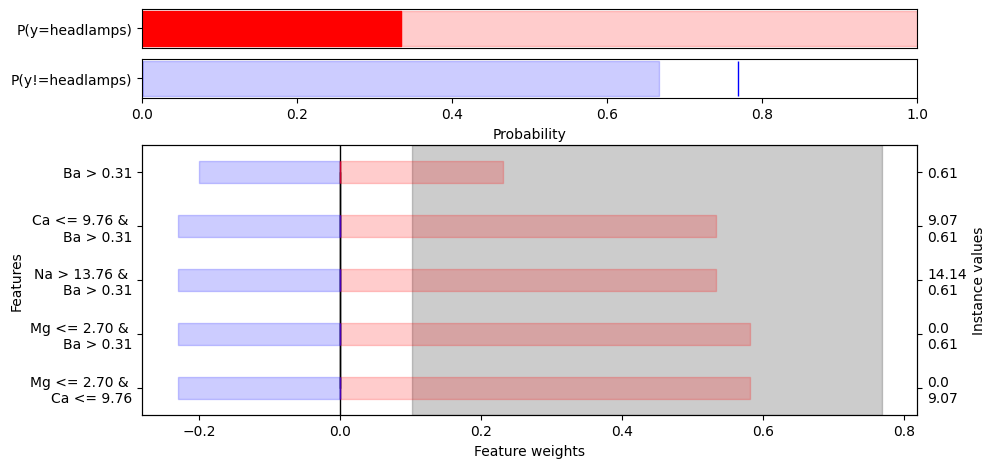

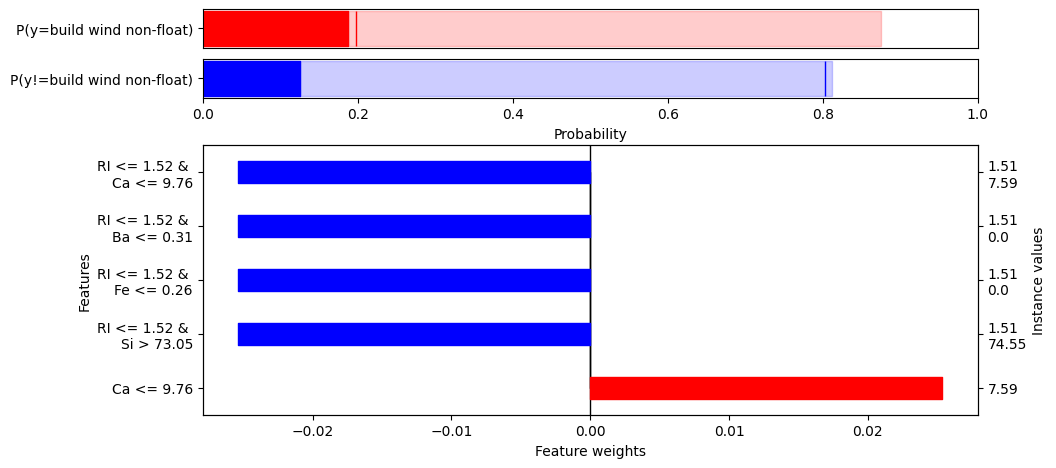

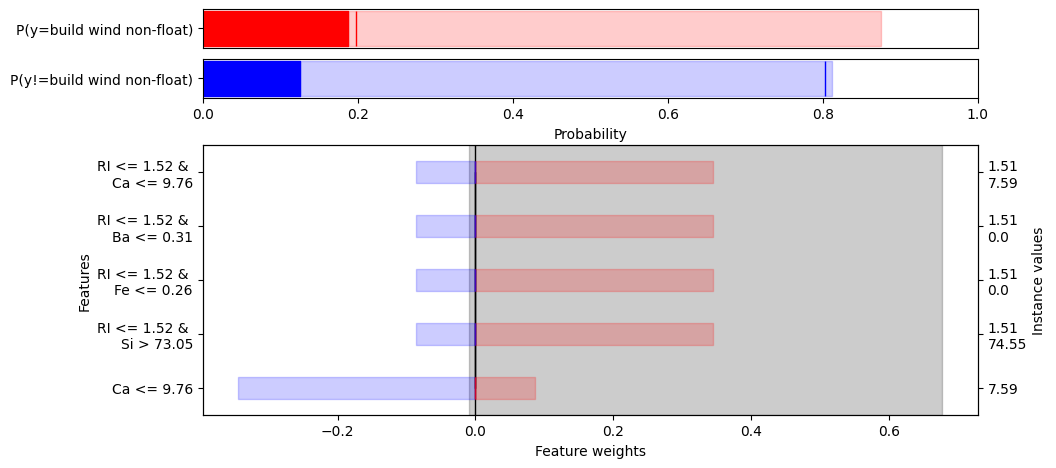

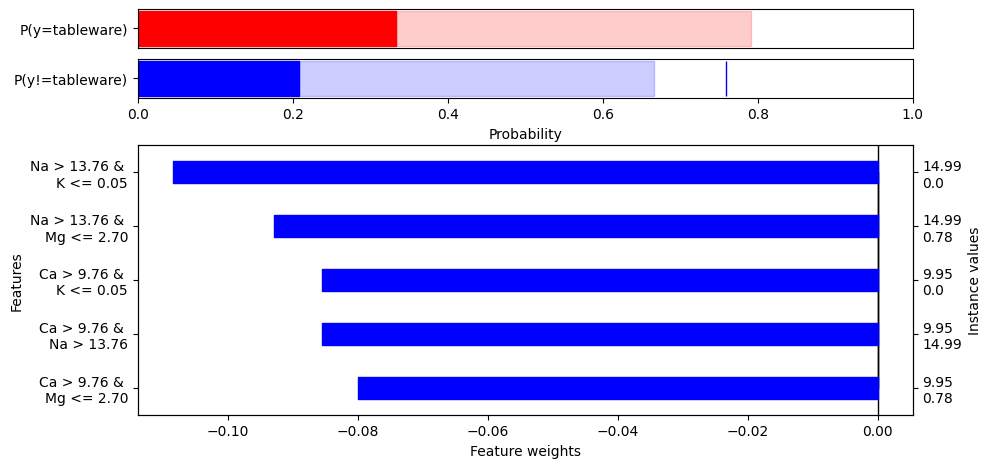

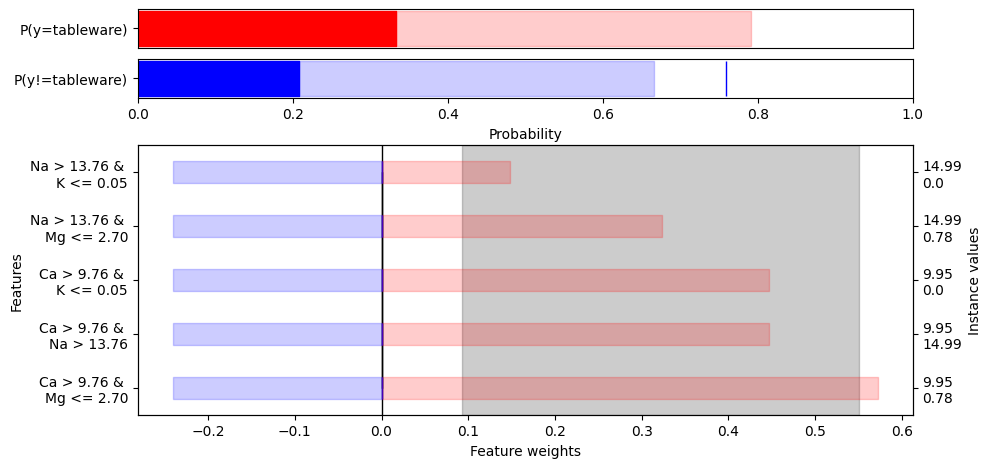

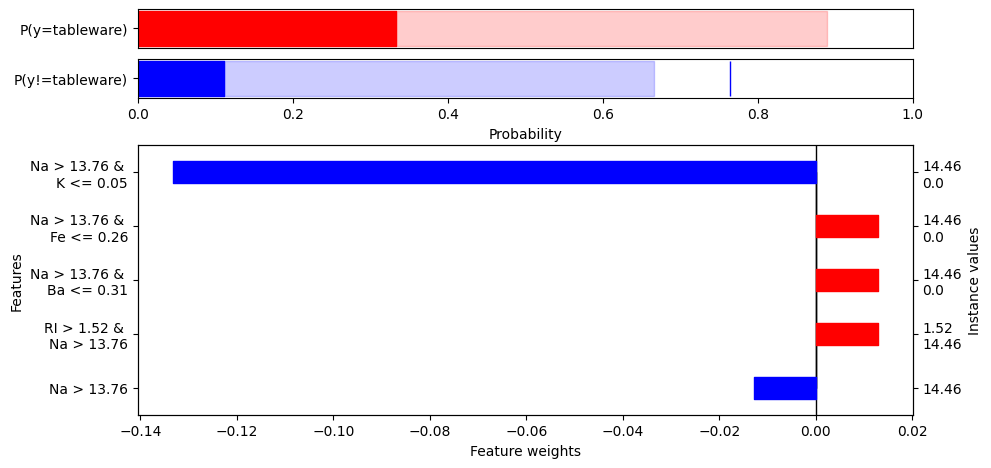

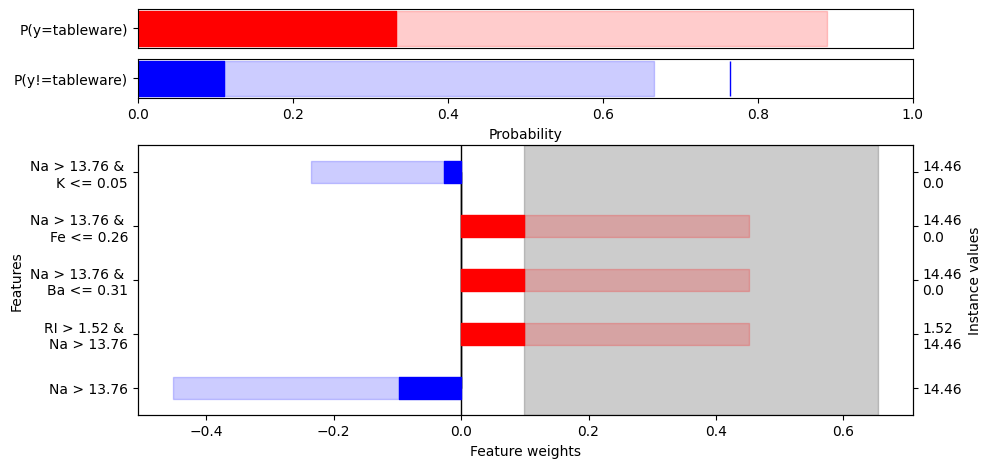

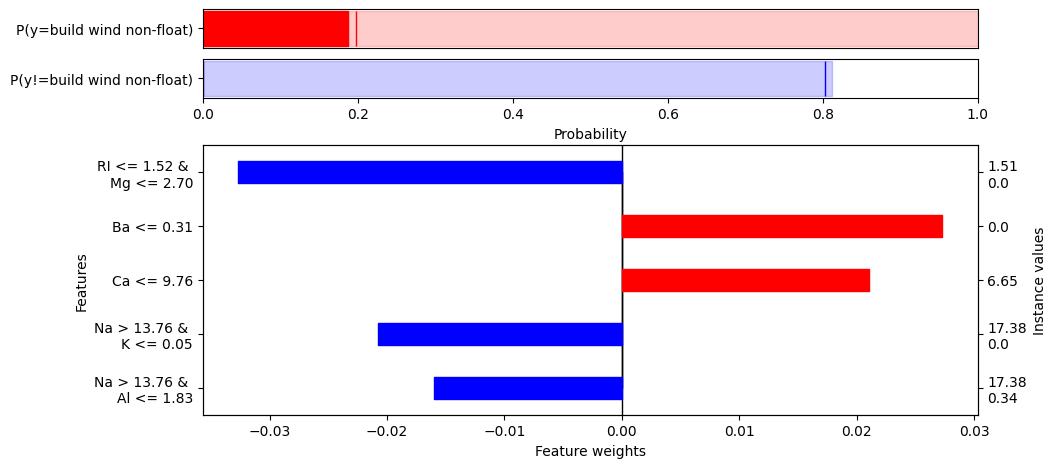

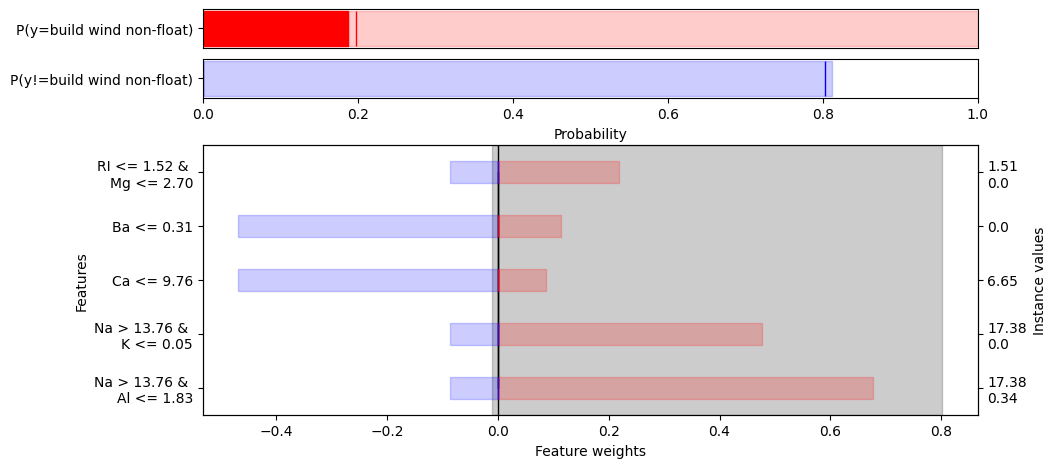

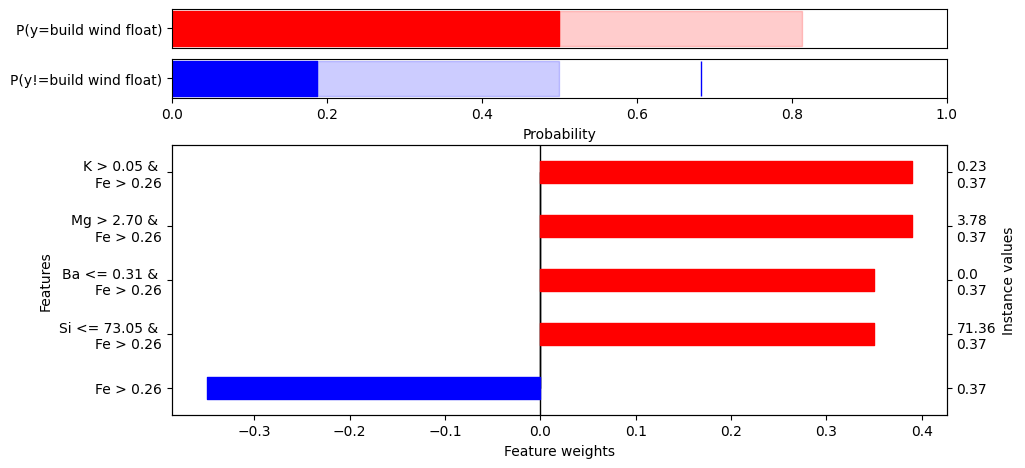

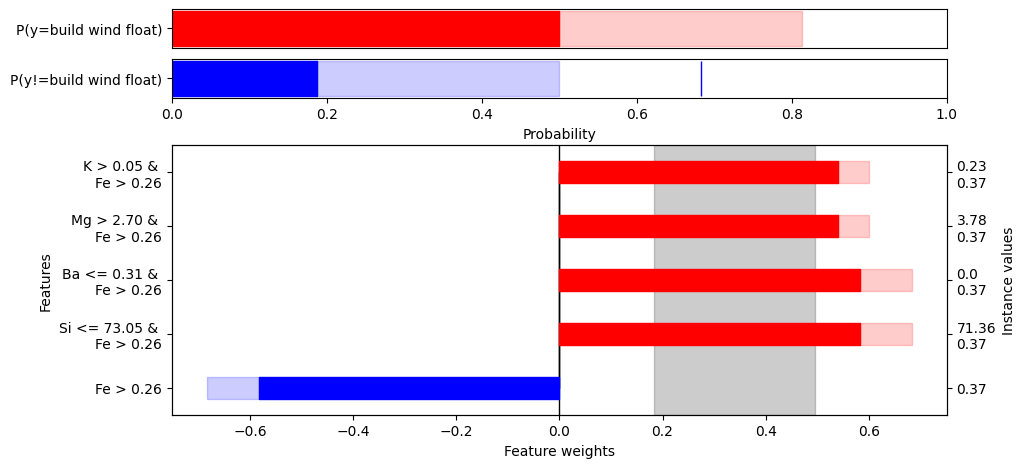

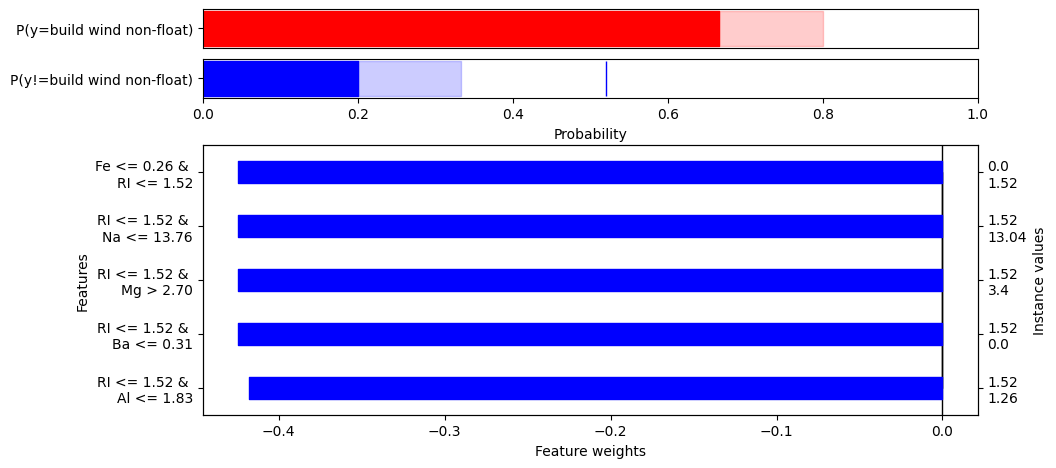

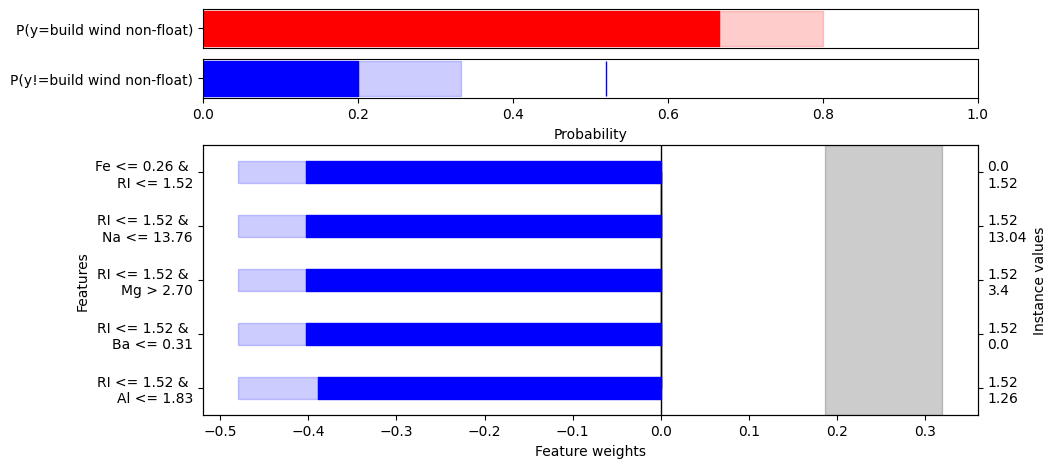

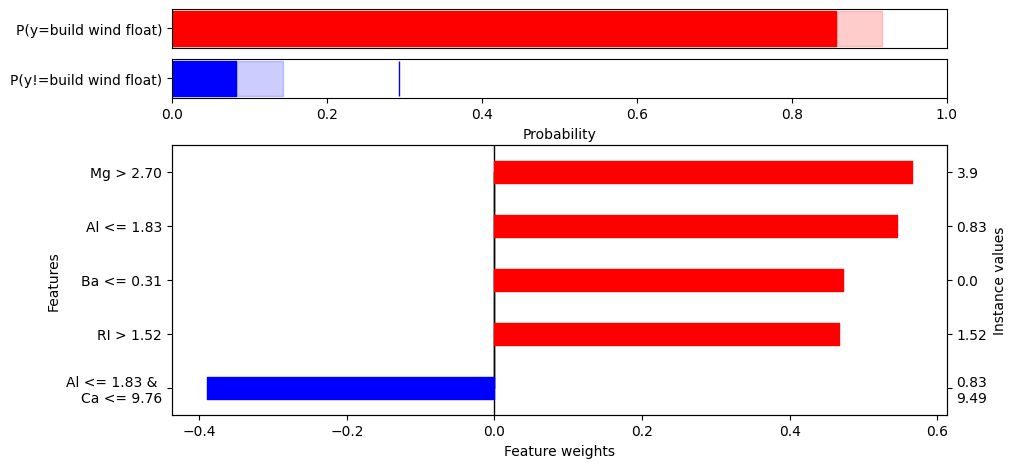

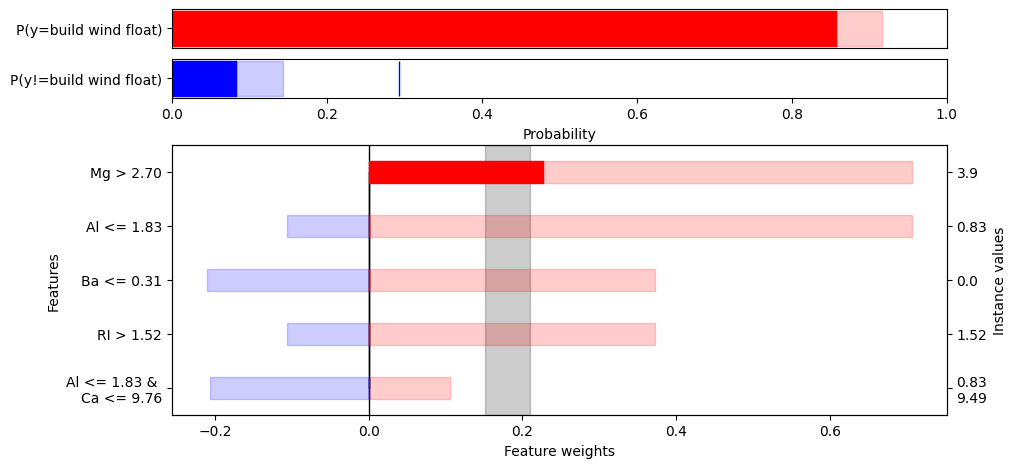

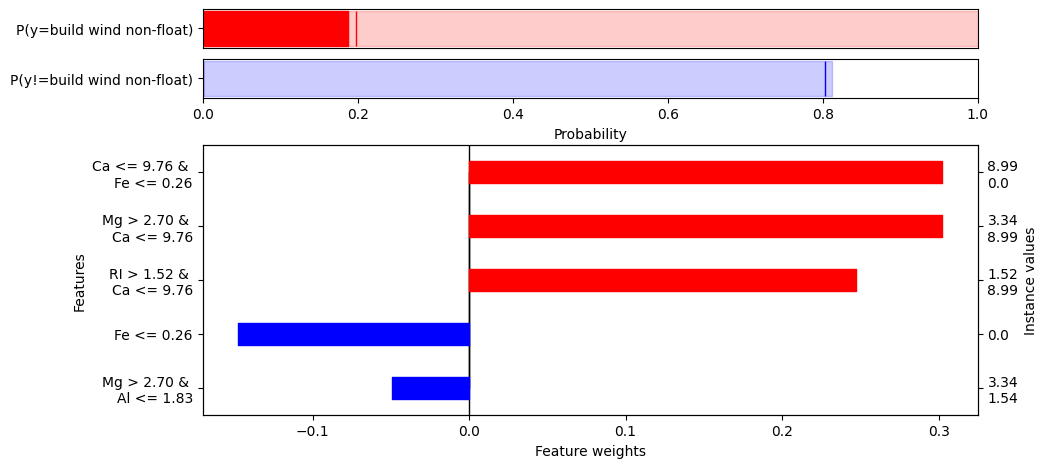

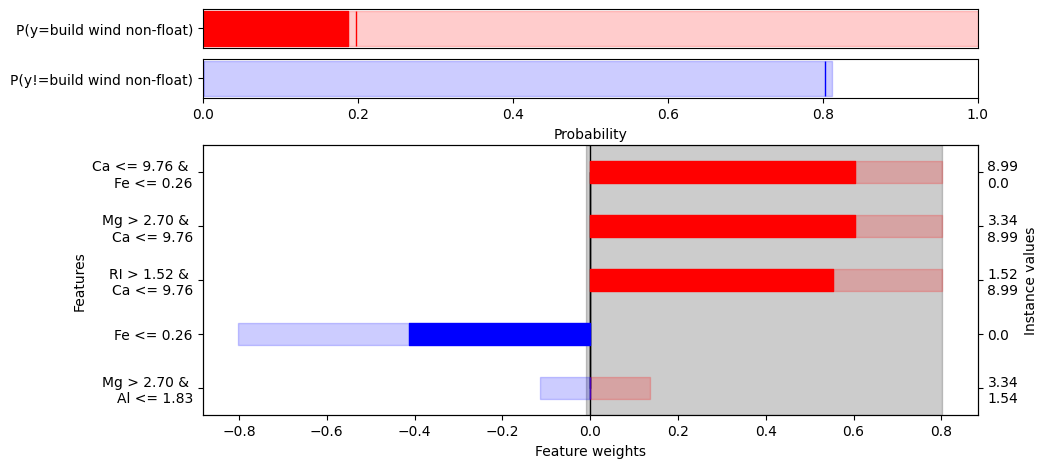

In [27]:
factual_explanations.add_conjunctions()
for i in range(num_to_test):
    explanation = factual_explanations[i]
    explanation.plot(
        filter_top=5,
        filename=f"{dataset}_{i}_c{y_test[i]}_p{predicted_classes[i]}_conjunctive_factual.png",
        show=True,
    )
    explanation.plot(
        uncertainty=True,
        filter_top=5,
        filename=f"{dataset}_{i}_c{y_test[i]}_p{predicted_classes[i]}_conjunctive_factual_uncertainty.png",
        show=True,
    )

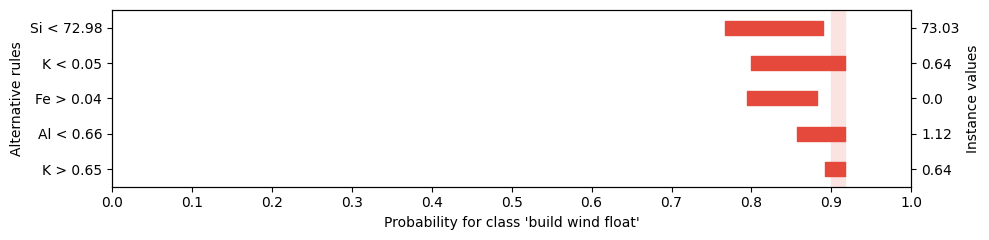

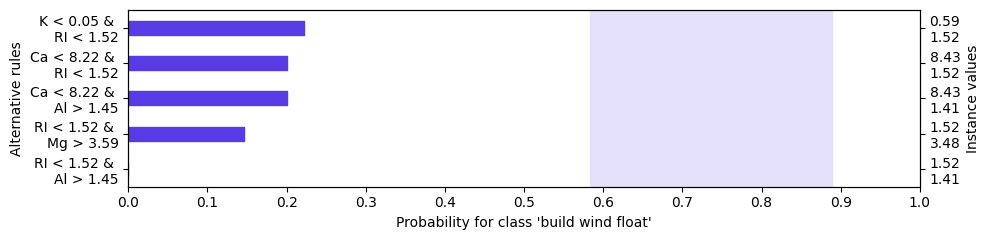

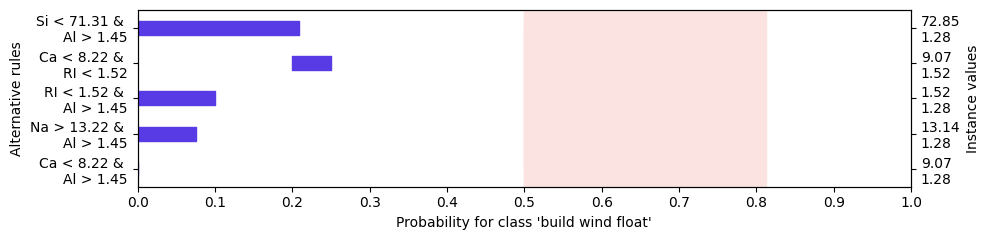

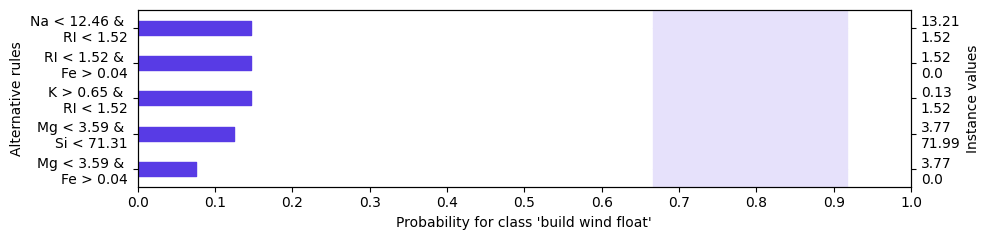

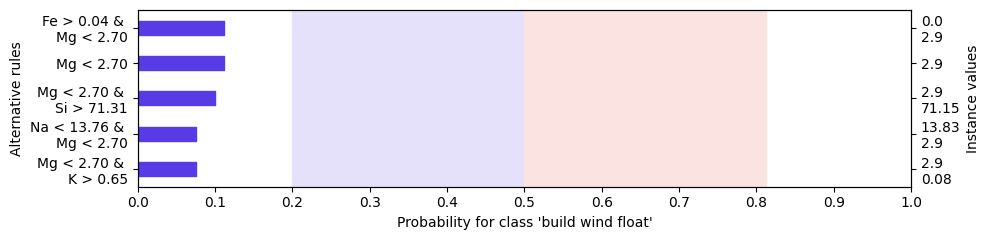

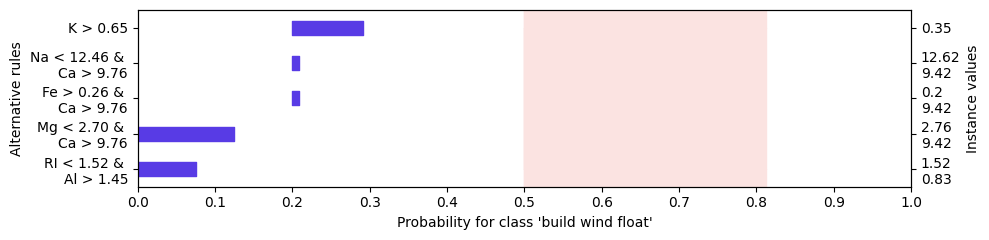

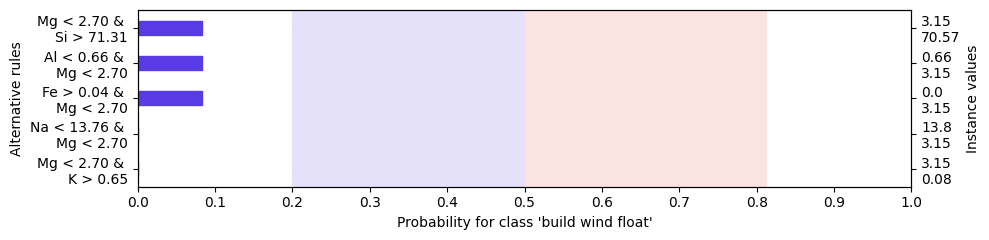

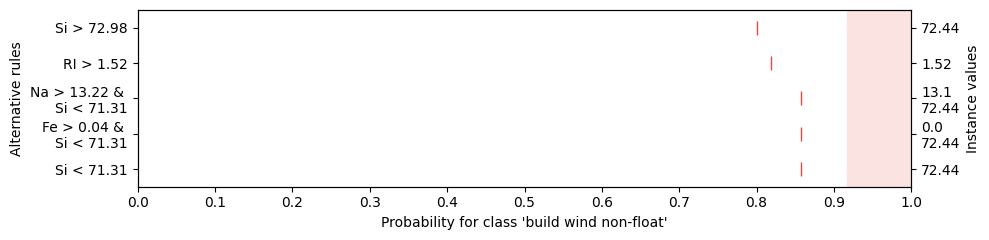

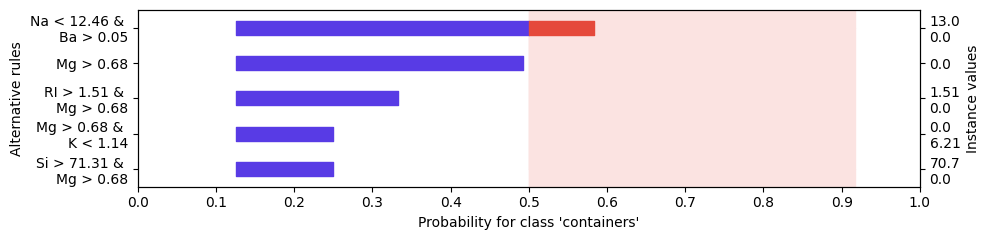

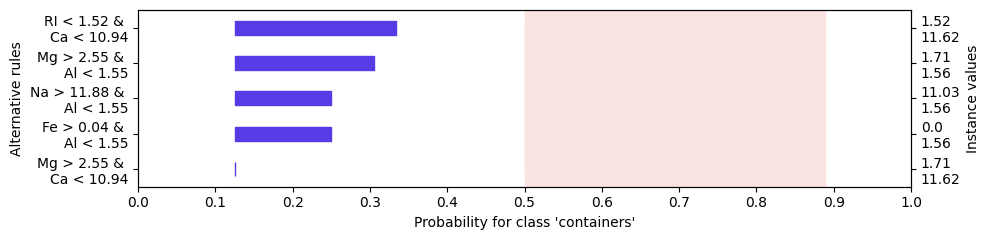

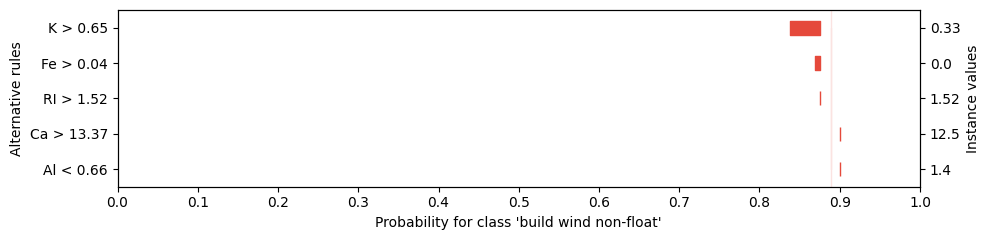

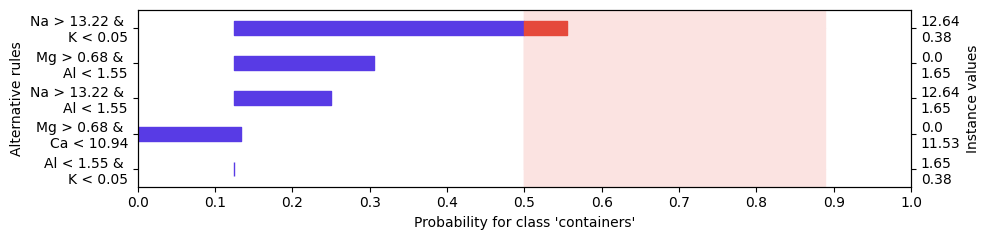

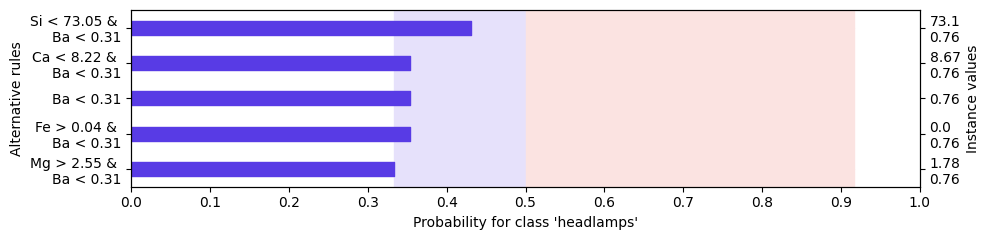

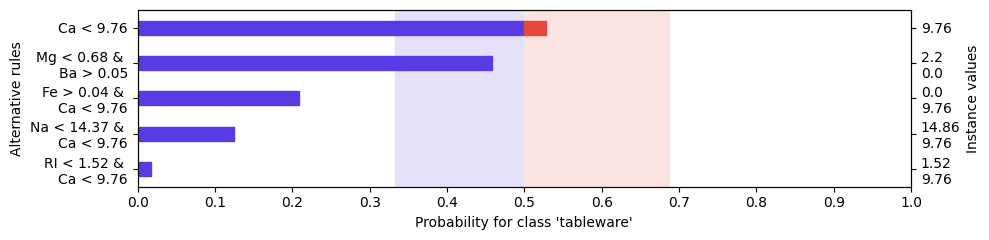

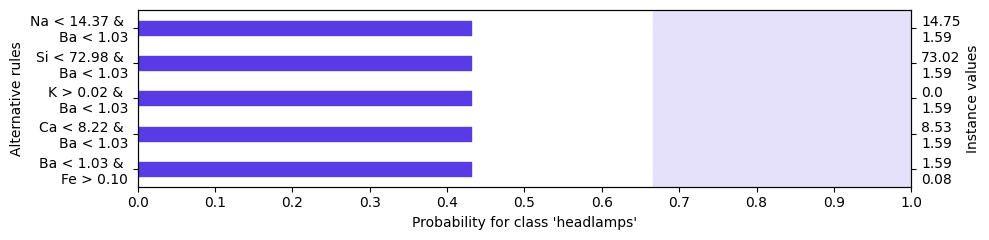

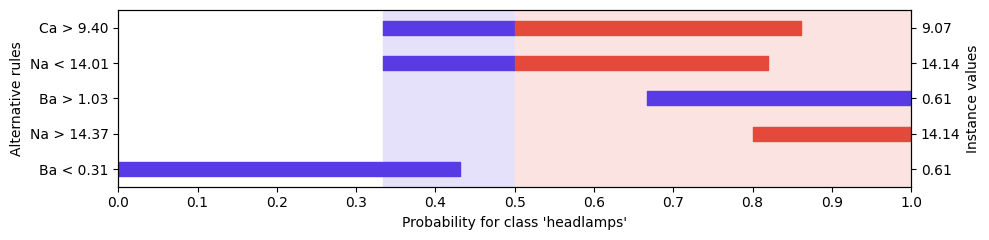

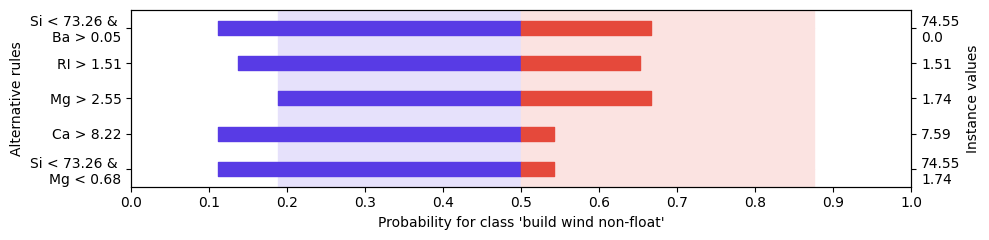

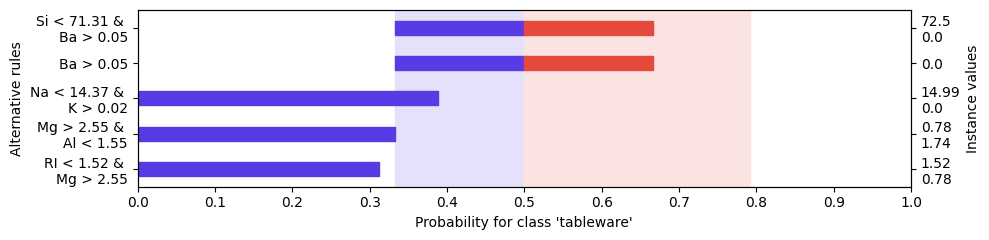

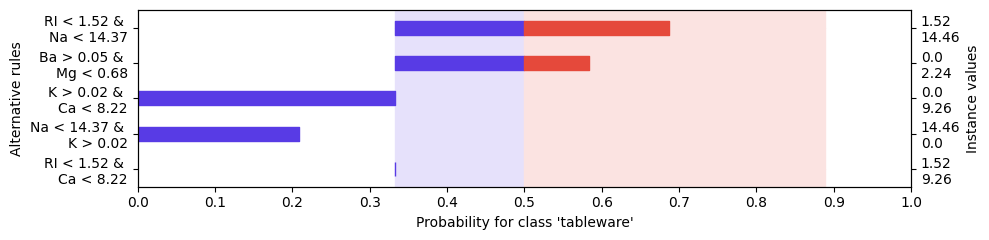

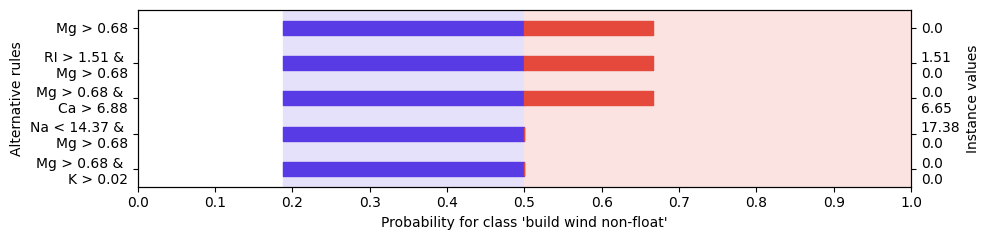

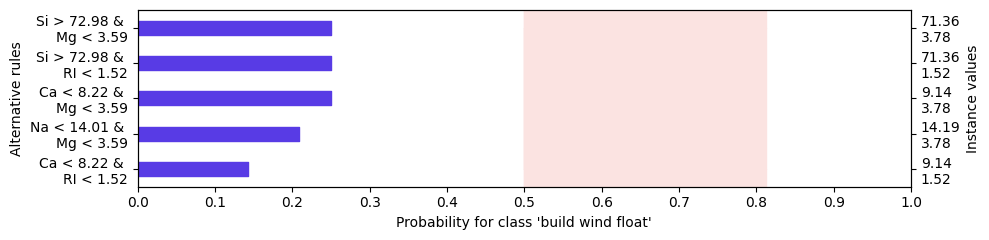

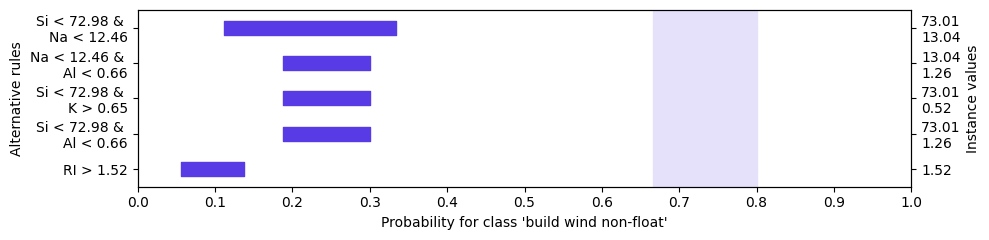

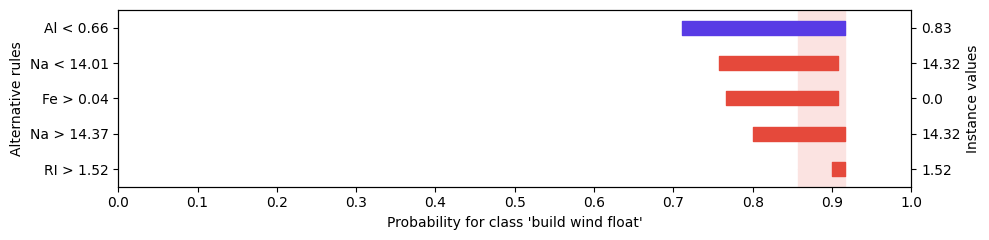

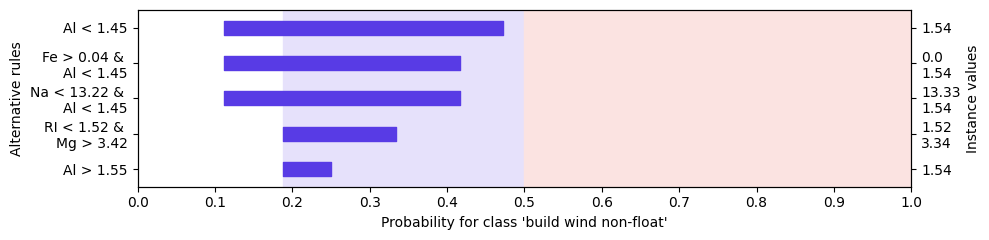

In [28]:
alternative_explanations.add_conjunctions()
for i in range(num_to_test):
    explanation = alternative_explanations[i]
    explanation.plot(
        filter_top=5,
        filename=f"{dataset}_{i}_c{y_test[i]}_p{predicted_classes[i]}_conjunctive_alternative.png",
        show=True,
    )